In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.optimize import least_squares
from scipy.interpolate import griddata
from IPython.display import Markdown, display

# Eurofer97 Radiation of Microstructure

## Neutron Damage

### 1) Mean PKA Energy for a 1 MeV Neutron in EUROFER97  

#### Average Atomic (Nucleus) Mass of EUROFER97  

Given target wt% (Fe balance):  
Fe 89.008, Cr 9.0, W 1.1, Mn 0.40, V 0.20, Ta 0.12, C 0.11, N 0.030, P 0.015, S 0.005, B 0.002, O 0.010  

Based on *Development of EUROFER97 database and material property handbook* (Ermile Gaganidze).

The number of moles of atoms per 100 g alloy is  

$$
n_i = \frac{w_i}{A_i}, \qquad 
\sum n_i = 1.7975~\text{mol-atoms/100 g}.
$$

Hence, the average atomic (nucleus) mass is  

$$
\bar{M} = \frac{100}{1.7975} = 55.63~\text{g mol}^{-1} \approx 55.6~\text{amu}.
$$
---
#### • Max transferable energy

$$
E_{\text{max}} = \frac{4A}{(1 + A)^2} E_n
= \frac{4 \times 56}{57^2} (1~\text{MeV})
\approx 0.069~\text{MeV} = 69~\text{keV}.
$$
---
#### • Mean PKA energy

A simple estimate for the mean PKA energy is about half of $E_{\text{max}}$:

$$
E_{\text{PKA}} \approx \tfrac{1}{2} E_{\text{max}} \approx 34.5~\text{keV}.
$$


### 2) Number of Displaced Atoms per Cascade

Take a representative displacement energy for Fe of $E_d \approx 40~\text{eV}$.
K. Nordlund *et al.*, *Philosophical Magazine 85* (2005),and Zarkadoula *et al.*, *J. Nucl. Mater.* (2016) report similar values.

---
#### • The Kinchin–Pease expression
$N_d \approx \frac{0.8 \times E_{\text{PKA}}}{2E_d}$

Using $\kappa = 0.8$, $E_{\text{PKA}} = 34.5~\text{keV} = 34{,}500~\text{eV}$, and $E_d = 40~\text{eV}$:

$N_d = \frac{0.8 \times 34{,}500}{2 \times 40}
     = \frac{27{,}600}{80}
     = 345$

$\boxed{N_d \approx 3.5 \times 10^2~\text{displacements per cascade}}$


### 3) Damage Rate for EUROFER97
Assume the same neutron flux (as in the Zr example):

- $\phi = 9.5\times10^{17}\ \text{n{\cdot}m}^{-2}\text{s}^{-1}$  
- Displacement cross-section for EUROFER97: $\sigma_d = 1.5\times10^{2}\ \text{barn}$  
  (based on *Shengli Chen et al., "New evaluation of neutron-induced displacement damage cross section for EUROFER97"*)  
- $1\ \text{barn} = 1\times10^{-28}\ \text{m}^2$

---

**Calculation**

$$
\sigma_d = 1.5\times10^{2}\ \text{barn}
= 1.5\times10^{-26}\ \text{m}^2
$$

$$
\phi\,\sigma_d = (9.5\times10^{17})(1.5\times10^{-26})
= 1.4\times10^{-8}\ \text{collisions{\cdot}s}^{-1}
$$

Convert to collisions per year:
$$
1.4\times10^{-8}\ \text{s}^{-1} \times 3.15\times10^{7}\ \text{s{\cdot}yr}^{-1}
= 0.44\ \text{collisions{\cdot}yr}^{-1}
$$

Each collision produces $N_d = 350$ displaced atoms:
$$
0.44\ \text{collisions{\cdot}yr}^{-1} \times 350
= 1.54\times10^{2}\ \text{dpa{\cdot}yr}^{-1}
$$

### 4) Fluence ↔ dpa conversion for EUROFER

fluence is c/m2 which is flux (phi) times time (t)

$$
\boxed{1~\text{dpa} = (6\text{–}7)\times10^{24}~\text{n{\cdot}m}^{-2}\;(E=1~\text{MeV})}.
$$


## 3.3. Electron Damage in Fe

### **Definition**

The displacement damage rate is given by

$$
\dot{d} = \phi\,\sigma_d
$$

where:  
- $\phi$ = incident electron flux (e·m⁻²·s⁻¹)  
- $\sigma_d$ = displacement cross-section (m²) for producing stable Frenkel pairs  
---
### **Displacement Cross-Section for 1 MeV Electrons in Fe**

Source for estimation: *Yosuke Iwamoto, “Implementing displacement damage calculations for electrons and gamma rays in the Particle and Heavy-Ion Transport code System (PHITS)”*.

For **1 MeV electrons**, the displacement cross-section for Fe (with a typical threshold displacement energy $E_d \approx 40$ eV) is approximately:

$$
\sigma_d \approx (1\text{–}5)\times10^{-27}\ \text{m}^2\qquad \approx \text{50 barn}
$$
---
### **Numerical Estimate**

Given:

$$
\phi = 4.6\times10^{22}\ \text{e{\cdot}m}^{-2}\text{s}^{-1}, \qquad
\sigma_d = 3\times10^{-27}\ \text{m}^2
$$

then

$$
\begin{aligned}
\dot{d} &= \phi\,\sigma_d \\
        &= (4.6\times10^{22})(3\times10^{-27}) \\
        &= 1.38\times10^{-4}\ \text{dpa{\cdot}s}^{-1}
\end{aligned}
$$
---
### **Result**

A representative value for **1 MeV electron irradiation of Fe (or EUROFER97)** is therefore:

$$
\boxed{\dot{d} \approx 1\times10^{-4}\ \text{dpa{\cdot}s}^{-1}}
$$


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

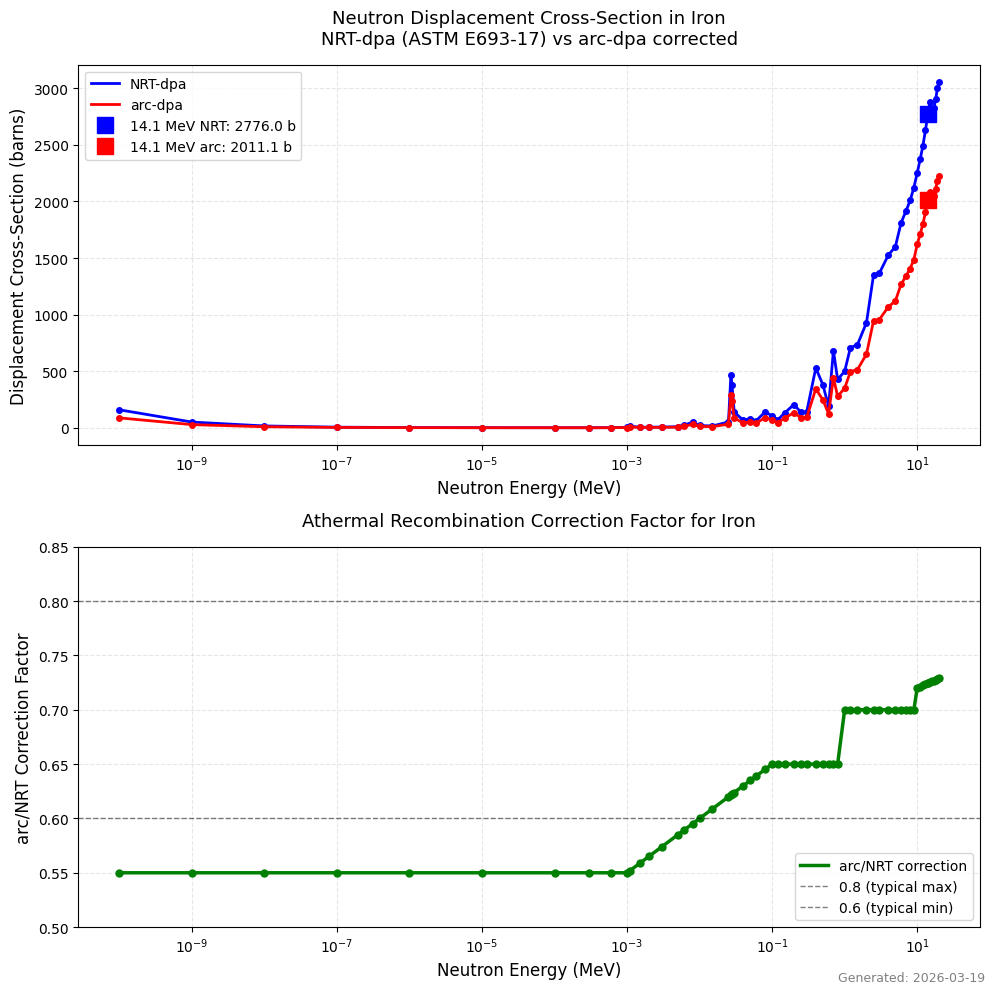


EXAMPLE USAGE

Iron Neutron Displacement Cross-Sections
Generated: 2026-03-19 17:45:04
   Energy (MeV)     NRT (barns)     arc (barns)      arc/NRT
--------------------------------------------------------------------------------
   2.530000e-08          513.39          282.36        0.550
   1.000000e-03            3.79            2.08        0.550
   1.000000e-01          105.50           68.57        0.650
   1.000000e+00          498.50          348.95        0.700
   1.410000e+01         2776.00         2011.15        0.724
   2.000000e+01         3056.40         2228.21        0.729

Notes:
  - NRT: Norgett-Robinson-Torrens model (ASTM E693-17)
  - arc: Athermal recombination corrected displacement
  - Data source: ENDF/B-VI nuclear data
  - arc-dpa accounts for defect recombination during cascade


Single energy query examples:

At 14.1 MeV (fusion neutrons):
  NRT-dpa:  2776.00 barns
  arc-dpa:  2011.15 barns
  Correction: 0.724

At 2.5 MeV (fission neutrons):
  NRT-dpa:  1349.

In [2]:
# ASTM E693-17 displacement cross-section data for natural iron
# Based on ENDF/B-VI, calculated using NJOY with NRT-dpa model
# Energy in MeV, cross-section in barns

energy_nrt = np.array([
    1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 0.0003,
    0.0006, 0.001, 0.0011, 0.0015, 0.002, 0.003, 0.005, 0.006,
    0.008, 0.01, 0.015, 0.025, 0.027, 0.028, 0.03, 0.04,
    0.05, 0.06, 0.08, 0.1, 0.12, 0.15, 0.2, 0.25,
    0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0, 1.2,
    1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 7.0,
    8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 14.1,
    15.0, 16.0, 17.0, 18.0, 19.0, 20.0
])

cross_section_nrt = np.array([
    158.35, 50.08, 15.84, 5.029, 1.596, 0.5003, 0.1462, 0.0715,
    0.723, 3.787, 13.14, 4.593, 5.111, 6.174, 8.911, 21.17,
    48.66, 19.98, 15.09, 51.59, 462.4, 374.2, 138.9, 65.56,
    80.55, 61.39, 139.4, 105.5, 70.47, 133.1, 205.3, 135.3,
    142.0, 528.4, 381.0, 190.8, 680.4, 427.2, 498.5, 707.2,
    734.2, 928.8, 1349.0, 1364.0, 1526.4, 1600.1, 1811.5, 1914.4,
    2009.1, 2122.6, 2250.5, 2371.7, 2493.7, 2630.3, 2763.2, 2776.0,
    2877.6, 2813.4, 2823.4, 2904.0, 2999.6, 3056.4
])

def calculate_arc_correction_factor(energy_mev):
    """
    Calculate arc-dpa correction factor for iron.
    Based on athermal recombination corrected displacement model.
    
    The arc-dpa model accounts for recombination of defects that occurs
    during the displacement cascade before the system thermalizes.
    
    Typical correction: arc-dpa = 0.6 to 0.8 * NRT-dpa for iron
    
    Parameters:
    -----------
    energy_mev : float or array
        Neutron energy in MeV
    
    Returns:
    --------
    float or array : arc correction factor (multiply NRT to get arc-dpa)
    
    References:
    -----------
    Nordlund et al., Nat. Commun. 9, 1084 (2018)
    Konobeyev et al., Nucl. Energy Technol. 3, 169-175 (2017)
    """
    energy = np.atleast_1d(energy_mev)
    
    # Empirical arc correction factor for iron based on MD simulations
    # Lower energies have higher recombination (lower surviving fraction)
    # Higher energies have more complex cascades with better survival
    
    correction = np.zeros_like(energy)
    
    # Energy-dependent correction based on literature
    # Below 1 keV: high recombination
    mask_low = energy < 0.001
    correction[mask_low] = 0.55
    
    # 1 keV - 100 keV: transition region
    mask_mid_low = (energy >= 0.001) & (energy < 0.1)
    correction[mask_mid_low] = 0.55 + 0.1 * np.log10(energy[mask_mid_low] / 0.001) / 2.0
    
    # 100 keV - 1 MeV: moderate recombination
    mask_mid = (energy >= 0.1) & (energy < 1.0)
    correction[mask_mid] = 0.65
    
    # 1 MeV - 10 MeV: typical fusion/fission range
    mask_high = (energy >= 1.0) & (energy < 10.0)
    correction[mask_high] = 0.70
    
    # Above 10 MeV: complex cascades, better survival
    mask_very_high = energy >= 10.0
    correction[mask_very_high] = 0.72 + 0.03 * np.log10(energy[mask_very_high] / 10.0)
    
    # Cap maximum at 0.8
    correction = np.minimum(correction, 0.8)
    
    return correction.item() if np.isscalar(energy_mev) else correction

# Calculate arc-dpa cross sections
arc_correction = calculate_arc_correction_factor(energy_nrt)
cross_section_arc = cross_section_nrt * arc_correction

# Create interpolation functions for both NRT and arc-dpa
interp_nrt = interp1d(energy_nrt, cross_section_nrt, kind='cubic', 
                      bounds_error=False, fill_value='extrapolate')
interp_arc = interp1d(energy_nrt, cross_section_arc, kind='cubic', 
                      bounds_error=False, fill_value='extrapolate')

def get_nrt_cross_section(energy_mev):
    """
    Get NRT-dpa displacement cross-section for iron at specified energy.
    
    Parameters:
    -----------
    energy_mev : float or array
        Neutron energy in MeV
    
    Returns:
    --------
    float or array : NRT displacement cross-section in barns
    """
    return interp_nrt(energy_mev)

def get_arc_cross_section(energy_mev):
    """
    Get arc-dpa displacement cross-section for iron at specified energy.
    
    Parameters:
    -----------
    energy_mev : float or array
        Neutron energy in MeV
    
    Returns:
    --------
    float or array : arc-dpa displacement cross-section in barns
    """
    return interp_arc(energy_mev)

def get_both_cross_sections(energy_mev):
    """
    Get both NRT and arc-dpa cross-sections for iron at specified energy.
    
    Parameters:
    -----------
    energy_mev : float or array
        Neutron energy in MeV
    
    Returns:
    --------
    dict : Dictionary with 'energy', 'nrt', 'arc', and 'correction_factor'
    """
    energy = np.atleast_1d(energy_mev)
    nrt = get_nrt_cross_section(energy)
    arc = get_arc_cross_section(energy)
    correction = arc / nrt
    
    result = {
        'energy_MeV': energy,
        'nrt_barns': nrt,
        'arc_barns': arc,
        'correction_factor': correction
    }
    
    # If scalar input, return scalar outputs
    if np.isscalar(energy_mev):
        result = {k: v.item() if hasattr(v, 'item') else v 
                  for k, v in result.items()}
    
    return result

def print_cross_section_table(energies_mev):
    """
    Print a formatted table of cross-sections at specified energies.
    
    Parameters:
    -----------
    energies_mev : list or array
        List of neutron energies in MeV
    """
    print("\n" + "="*80)
    print("Iron Neutron Displacement Cross-Sections")
    print(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("="*80)
    print(f"{'Energy (MeV)':>15} {'NRT (barns)':>15} {'arc (barns)':>15} {'arc/NRT':>12}")
    print("-"*80)
    
    for E in energies_mev:
        data = get_both_cross_sections(E)
        print(f"{data['energy_MeV']:>15.6e} {data['nrt_barns']:>15.2f} "
              f"{data['arc_barns']:>15.2f} {data['correction_factor']:>12.3f}")
    
    print("="*80)
    print("\nNotes:")
    print("  - NRT: Norgett-Robinson-Torrens model (ASTM E693-17)")
    print("  - arc: Athermal recombination corrected displacement")
    print("  - Data source: ENDF/B-VI nuclear data")
    print("  - arc-dpa accounts for defect recombination during cascade")
    print("="*80 + "\n")

# Create the plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Plot 1: Both cross-sections
ax1.plot(energy_nrt, cross_section_nrt, 'b-', linewidth=2, label='NRT-dpa')
ax1.plot(energy_nrt, cross_section_nrt, 'bo', markersize=4)
ax1.plot(energy_nrt, cross_section_arc, 'r-', linewidth=2, label='arc-dpa')
ax1.plot(energy_nrt, cross_section_arc, 'ro', markersize=4)

# Highlight 14.1 MeV point
idx_14_1 = np.where(energy_nrt == 14.1)[0][0]
ax1.plot(14.1, cross_section_nrt[idx_14_1], 'bs', markersize=12, 
        label=f'14.1 MeV NRT: {cross_section_nrt[idx_14_1]:.1f} b')
ax1.plot(14.1, cross_section_arc[idx_14_1], 'rs', markersize=12,
        label=f'14.1 MeV arc: {cross_section_arc[idx_14_1]:.1f} b')

ax1.set_xscale('log')
ax1.set_xlabel('Neutron Energy (MeV)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Displacement Cross-Section (barns)', fontsize=12, fontweight='bold')
ax1.set_title('Neutron Displacement Cross-Section in Iron\n' +
              'NRT-dpa (ASTM E693-17) vs arc-dpa corrected', 
              fontsize=13, fontweight='bold', pad=15)
ax1.grid(True, which='both', alpha=0.3, linestyle='--')
ax1.legend(loc='best', fontsize=10)

# Plot 2: Correction factor
ax2.plot(energy_nrt, arc_correction, 'g-', linewidth=2.5, label='arc/NRT correction')
ax2.plot(energy_nrt, arc_correction, 'go', markersize=5)
ax2.axhline(y=0.8, color='k', linestyle='--', linewidth=1, alpha=0.5, label='0.8 (typical max)')
ax2.axhline(y=0.6, color='k', linestyle='--', linewidth=1, alpha=0.5, label='0.6 (typical min)')

ax2.set_xscale('log')
ax2.set_xlabel('Neutron Energy (MeV)', fontsize=12, fontweight='bold')
ax2.set_ylabel('arc/NRT Correction Factor', fontsize=12, fontweight='bold')
ax2.set_title('Athermal Recombination Correction Factor for Iron', 
              fontsize=13, fontweight='bold', pad=15)
ax2.grid(True, which='both', alpha=0.3, linestyle='--')
ax2.legend(loc='best', fontsize=10)
ax2.set_ylim([0.5, 0.85])

# Add date stamp
current_date = datetime.now().strftime('%Y-%m-%d')
fig.text(0.99, 0.01, f'Generated: {current_date}', 
         ha='right', va='bottom', fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.show()

# Example usage
print("\n" + "="*80)
print("EXAMPLE USAGE")
print("="*80)

# Query specific energies
test_energies = [0.0253e-6, 0.001, 0.1, 1.0, 14.1, 20.0]  # thermal, keV, MeV range
print_cross_section_table(test_energies)

# Single energy query
print("\nSingle energy query examples:")
print(f"\nAt 14.1 MeV (fusion neutrons):")
data_fusion = get_both_cross_sections(14.1)
print(f"  NRT-dpa:  {data_fusion['nrt_barns']:.2f} barns")
print(f"  arc-dpa:  {data_fusion['arc_barns']:.2f} barns")
print(f"  Correction: {data_fusion['correction_factor']:.3f}")

print(f"\nAt 2.5 MeV (fission neutrons):")
data_fission = get_both_cross_sections(2.5)
print(f"  NRT-dpa:  {data_fission['nrt_barns']:.2f} barns")
print(f"  arc-dpa:  {data_fission['arc_barns']:.2f} barns")
print(f"  Correction: {data_fission['correction_factor']:.3f}")

print(f"\nAt thermal (0.0253 eV = 2.53e-8 MeV):")
data_thermal = get_both_cross_sections(2.53e-8)
print(f"  NRT-dpa:  {data_thermal['nrt_barns']:.2f} barns")
print(f"  arc-dpa:  {data_thermal['arc_barns']:.2f} barns")
print(f"  Correction: {data_thermal['correction_factor']:.3f}")

# Array query
print("\n\nArray query example:")
energies_array = np.array([1.0, 5.0, 10.0, 14.1, 15.0])
results_array = get_both_cross_sections(energies_array)
print(f"Energies: {results_array['energy_MeV']}")
print(f"NRT:      {results_array['nrt_barns']}")
print(f"arc:      {results_array['arc_barns']}")

print("\n" + "="*80)
print("Available functions:")
print("  - get_nrt_cross_section(energy_mev)")
print("  - get_arc_cross_section(energy_mev)")
print("  - get_both_cross_sections(energy_mev)")
print("  - calculate_arc_correction_factor(energy_mev)")
print("  - print_cross_section_table(energies_list)")
print("="*80 + "\n")

E =  0.10 MeV  →  σ_NRT ≈    43.4 b,   σ_ARC ≈    26.5 b
E =  1.00 MeV  →  σ_NRT ≈   300.0 b,   σ_ARC ≈   212.6 b
E = 14.00 MeV  →  σ_NRT ≈  2750.0 b,   σ_ARC ≈  2108.9 b

At 14 MeV, flux=1.0e+14 n/cm^2/s → rate ≈ 2.75e-07 dpa/s,  in 1 day ≈ 2.38e-02 dpa


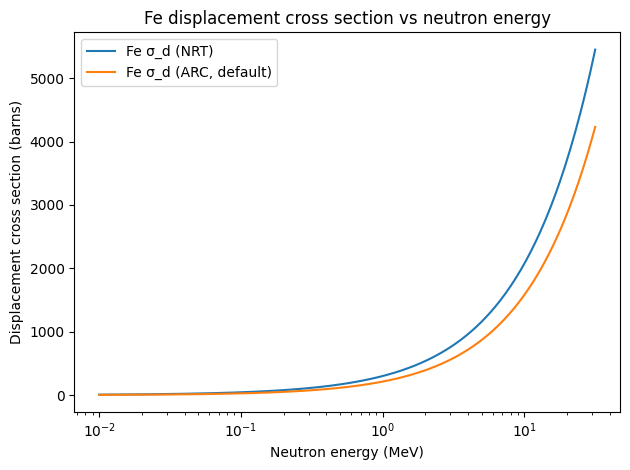

In [3]:
BARN = 1e-24  # cm^2

# ---------------------------
# Core formulas
# ---------------------------
def sigma_nrt_from_kappa(kappa_eV_b, E_d_eV=40.0):
    """
    NRT displacement cross section from damage-energy cross-section κ (eV·barn):
        σ_d^NRT(E) = κ(E) / (2 E_d)
    Returns barns (b).
    """
    return np.asarray(kappa_eV_b) / (2.0 * E_d_eV)

def sigma_arc_from_kappa(kappa_eV_b, E_d_eV=40.0, arc_factor=None, E_MeV=None):
    """
    ARC-dpa cross section:
        σ_d^ARC(E) = σ_d^NRT(E) * f_arc(E)
    arc_factor:
        - If array-like: same shape as kappa_eV_b (values ~0.3–0.9 typically)
        - If callable: arc_factor(E_MeV) must return array of same shape
        - If None: use a light-weight default 'Nordlund-like' shape (see below)
    Returns barns (b).
    """
    sigma_nrt = sigma_nrt_from_kappa(kappa_eV_b, E_d_eV)

    if arc_factor is None:
        # Default: simple monotonic curve ~0.3 at ~10 keV → ~0.8 above ~1 MeV
        # (loosely consistent with common ARC trends; replace if you have a library-specific factor)
        if E_MeV is None:
            raise ValueError("Provide E_MeV when arc_factor=None so a default curve can be generated.")
        E = np.asarray(E_MeV)
        # Smooth logistic-ish ramp in logE
        x = np.log10(np.clip(E, 1e-5, None))  # avoid log(0)
        f = 0.3 + 0.5 / (1.0 + np.exp(-(x + 1.5)))  # ~0.3 → ~0.8 between ~10 keV and ~1–10 MeV
        arc = f
    elif callable(arc_factor):
        if E_MeV is None:
            raise ValueError("arc_factor is callable: provide E_MeV so it can be evaluated.")
        arc = np.asarray(arc_factor(E_MeV))
    else:
        arc = np.asarray(arc_factor)

    return sigma_nrt * arc

def dpa_rate_per_atom(sigma_b, flux_n_cm2_s):
    """
    dpa rate (per atom) = flux [n/cm^2/s] × σ_d [barn] × 1e-24
    """
    return np.asarray(flux_n_cm2_s) * np.asarray(sigma_b) * BARN

def dpa_over_time(sigma_b, flux_n_cm2_s, time_s):
    """
    dpa over an exposure = dpa_rate_per_atom × time
    """
    return dpa_rate_per_atom(sigma_b, flux_n_cm2_s) * time_s

# ---------------------------
# Bring/fit your own κ(E)
# ---------------------------
# If you already have κ(E) from NJOY/HEATR or a library CSV, feed it directly.
# For convenience, here is a light power-law fit for Fe that roughly matches
# ~24 keV·b at 1 MeV (≈300 b NRT with Ed=40 eV) and ~220 keV·b at 14 MeV (≈2750 b).
def kappa_fe_example_fit(E_MeV):
    """
    Approx κ(E) [eV·barn] for bcc Fe, rough ENDF/B-VIII-like trend:
      κ(1 MeV) ≈ 24 keV·b, κ(14 MeV) ≈ 220 keV·b (power-law in E).
    Replace with your library κ(E) for precise work.
    """
    E = np.asarray(E_MeV, float)
    # Fit κ(E) = A * E^p with anchors (1 MeV, 24e3 eV·b) and (14 MeV, 2.2e5 eV·b)
    A1, E1 = 24e3, 1.0
    A2, E2 = 2.2e5, 14.0
    p = np.log(A2/A1) / np.log(E2/E1)
    A = A1 / (E1**p)
    return A * (E**p)

# ---------------------------
# Convenience wrappers
# ---------------------------
def sigma_fe_nrt(E_MeV, E_d_eV=40.0, kappa_fn=kappa_fe_example_fit):
    return sigma_nrt_from_kappa(kappa_fn(E_MeV), E_d_eV)

def sigma_fe_arc(E_MeV, E_d_eV=40.0, kappa_fn=kappa_fe_example_fit, arc_factor=None):
    kappa = kappa_fn(E_MeV)
    return sigma_arc_from_kappa(kappa, E_d_eV=E_d_eV, arc_factor=arc_factor, E_MeV=E_MeV)

# ---------------------------
# Example usage
# ---------------------------
if __name__ == "__main__":
    # Energy grid (MeV)
    E = np.logspace(-2, 1.5, 300)  # 0.01–100 MeV

    # Cross sections (barn)
    sigmaN = sigma_fe_nrt(E)             # NRT
    sigmaA = sigma_fe_arc(E)             # ARC with default correction

    # Specific values (feel free to change)
    for E0 in [0.1, 1.0, 14.0]:
        sN = float(sigma_fe_nrt(E0))
        sA = float(sigma_fe_arc(E0))
        print(f"E = {E0:>5.2f} MeV  →  σ_NRT ≈ {sN:7.1f} b,   σ_ARC ≈ {sA:7.1f} b")

    # Example: dpa rate and dose for a monoenergetic 14 MeV flux
    flux = 1e14  # n/cm^2/s
    sN_14 = sigma_fe_nrt(14.0)
    rate_dpa_s = dpa_rate_per_atom(sN_14, flux)
    dose_1d = dpa_over_time(sN_14, flux, 24*3600)
    print(f"\nAt 14 MeV, flux={flux:.1e} n/cm^2/s → rate ≈ {rate_dpa_s:.2e} dpa/s,  in 1 day ≈ {dose_1d:.2e} dpa")

    # Quick plot
    plt.semilogx(E, sigmaN, label="Fe σ_d (NRT)")
    plt.semilogx(E, sigmaA, label="Fe σ_d (ARC, default)")
    plt.xlabel("Neutron energy (MeV)")
    plt.ylabel("Displacement cross section (barns)")
    plt.title("Fe displacement cross section vs neutron energy")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Irradiated Microstructure

### Dislocation Loop Character

In **bcc materials** subjected to neutron irradiation, dislocation loops typically form with either **½〈111〉** or **〈100〉** Burgers vectors.

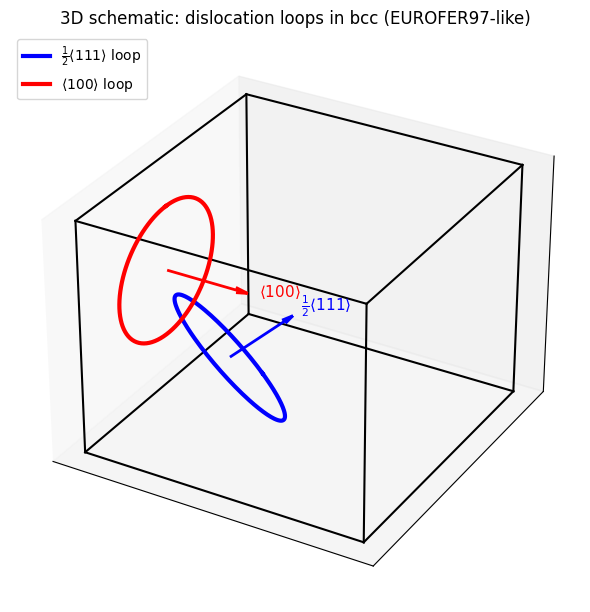

In [4]:
def draw_cube(ax, a=1.0, lw=1.5, color='black'):
    pts = np.array([[0,0,0],[a,0,0],[a,a,0],[0,a,0], [0,0,a],[a,0,a],[a,a,a],[0,a,a]], dtype=float)
    edges = [(0,1),(1,2),(2,3),(3,0), (4,5),(5,6),(6,7),(7,4), (0,4),(1,5),(2,6),(3,7)]
    for i, j in edges:
        xs, ys, zs = zip(pts[i], pts[j])
        ax.plot(xs, ys, zs, color=color, linewidth=lw)

def circle_on_plane(normal, point, radius, npts=200):
    n = np.array(normal, dtype=float)
    n = n / np.linalg.norm(n)
    a_vec = np.array([1.0,0.0,0.0])
    if np.allclose(n, np.array([1.0,0.0,0.0]), atol=1e-6):
        a_vec = np.array([0.0,1.0,0.0])
    u = np.cross(n, a_vec); u /= np.linalg.norm(u)
    v = np.cross(n, u); v /= np.linalg.norm(v)
    t = np.linspace(0, 2*np.pi, npts)
    c = np.array(point, dtype=float)
    pts = point[:, None] + radius * (u[:, None]*np.cos(t) + v[:, None]*np.sin(t))
    return pts

fig = plt.figure(figsize=(6, 7))
ax = fig.add_subplot(111, projection="3d")
a = 1.0
draw_cube(ax, a=a, color='black', lw=1.5)

# ---- 1) 1/2<111> loop ----
normal_111 = np.array([1, 1, 1])
center_111 = np.array([a/3, a/3, a/3])
loop_111 = circle_on_plane(normal=normal_111, point=center_111, radius=0.28*a)
ax.plot(loop_111[0], loop_111[1], loop_111[2],
        color='blue', linewidth=3, label=r"$\frac{1}{2}\langle111\rangle$ loop")

b_dir_111 = normal_111 / np.linalg.norm(normal_111)
ax.quiver(center_111[0], center_111[1], center_111[2],
          0.25*b_dir_111[0], 0.25*b_dir_111[1], 0.25*b_dir_111[2],
          color='blue', arrow_length_ratio=0.15, linewidth=2)
ax.text(center_111[0]+0.28*b_dir_111[0],
        center_111[1]+0.28*b_dir_111[1],
        center_111[2]+0.28*b_dir_111[2],
        r"$\frac{1}{2}\langle111\rangle$", color='blue', fontsize=11)

# ---- 2) <100> loop ----
normal_100 = np.array([1, 0, 0])
center_100 = np.array([0, a/2, a/2])
loop_100 = circle_on_plane(normal_100, center_100, radius=0.28*a)
ax.plot(loop_100[0], loop_100[1], loop_100[2], color='red', linewidth=3, label=r"$\langle100\rangle$ loop")
b_dir_100 = np.array([1.0, 0.0, 0.0])
ax.quiver(center_100[0], center_100[1], center_100[2],
          0.3*b_dir_100[0], 0.3*b_dir_100[1], 0.3*b_dir_100[2],
          color='red', arrow_length_ratio=0.15, linewidth=2)
ax.text(center_100[0]+0.34, center_100[1], center_100[2], r"$\langle100\rangle$", color='red', fontsize=11)

ax.set_title("3D schematic: dislocation loops in bcc (EUROFER97-like)")
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
ax.grid(False)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [5]:
def fit_lognormal(x, A, mean, std):
    sigma = np.sqrt(np.log(1 + (std / mean)**2))
    mu = np.log(mean) - 0.5 * sigma**2
    return A * (1 / (x * sigma * np.sqrt(2 * np.pi))) * np.exp(- (np.log(x) - mu)**2 / (2 * sigma**2))

In [6]:
df = pd.read_excel("../../docs/Database/MicroData.xlsx", sheet_name="Sheet1")

groups = {
    "350C_3dpa": [0, 1],
    "300C_15dpa_area1": [3, 4],
    "300C_15dpa_area2": [6, 7],
    "300C_15dpa_area3": [9, 10],
    "350C_16dpa_100": [12, 13],
    "350C_16dpa_111": [15, 16],
}

datasets = {}
for name, cols in groups.items():
    sub = df.iloc[1:, cols].dropna(how="all").copy()
    sub.columns = [df.iloc[0, cols[0]], df.iloc[0, cols[1]]]  # use header row
    sub.reset_index(drop=True, inplace=True)
    datasets[name] = sub

#### Dethloff et al. - 2016 - Microstructural defects in EUROFER 97 after different neutron irradiation conditions

At an irradiation dose of **15 dpa** and a temperature of **300 °C**, the **½〈111〉** loops are generally **larger in size but fewer in number** compared to the **〈100〉** loops.  

The measured dislocation loop densities are:
$N_{\langle100\rangle} = 4.9 \times 10^{21}~\text{m}^{-3}$,  
$N_{\frac{1}{2}\langle111\rangle} = 1.4 \times 10^{21}~\text{m}^{-3}$  
giving a total loop density of: $N_{\text{tot}} = 6.3 \times 10^{21}~\text{m}^{-3}$.

| Burgers vector type | Diffraction condition | Zone axis | Mean diameter (nm) |
|----------------------|----------------------|------------|--------------------|
| ½〈111〉 | g = {3-10}, [13-5] | Area 1 | 4.1 |
| 〈100〉 | g = {2-11}, [011] | Area 2 | 2.8 |
| ½〈111〉 | g = {200}, [011] | Area 2 | 4.2 |


Lognormal fit parameters:
  A = 0.995
  mean = 4.10 nm
  std  = 2.27 nm

Fitted lognormal moments:
  Mean     = 4.10 nm
  Variance = 5.17 nm^2  (Std = 2.27 nm)
  Skewness = 1.836
  Kurtosis = 12.535


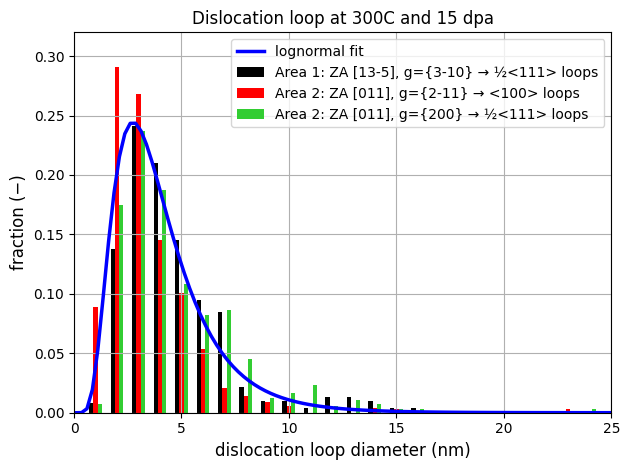

In [7]:
plt.bar(datasets["300C_15dpa_area1"]["Diameter"]-0.2, datasets["300C_15dpa_area1"]["Fraction"], width=0.2, color='black', label='Area 1: ZA [13-5], g={3-10} → ½<111> loops')
plt.bar(datasets["300C_15dpa_area2"]["Diameter"], datasets["300C_15dpa_area2"]["Fraction"], width=0.2, color='red', label='Area 2: ZA [011], g={2-11} → <100> loops')
plt.bar(datasets["300C_15dpa_area2"]["Diameter"]+0.2, datasets["300C_15dpa_area3"]["Fraction"], width=0.2, color='limegreen', label='Area 2: ZA [011], g={200} → ½<111> loops')

x_all = np.concatenate([datasets["300C_15dpa_area1"]["Diameter"], datasets["300C_15dpa_area2"]["Diameter"], datasets["300C_15dpa_area3"]["Diameter"]])
y_all = np.concatenate([datasets["300C_15dpa_area1"]["Fraction"], datasets["300C_15dpa_area2"]["Fraction"], datasets["300C_15dpa_area3"]["Fraction"]])

mask = y_all > 0
x_all = x_all[mask]
y_all = y_all[mask]

p0 = [max(y_all), np.mean(x_all), np.std(x_all)] # Initial guesses: A, mean, std
popt, pcov = curve_fit(fit_lognormal, x_all, y_all, p0=p0, maxfev=10000)
A_fit, mean_fit, std_fit = popt

xfit = np.linspace(0.1, 25, 100)
yfit = fit_lognormal(xfit, *popt)

sigma = np.sqrt(np.log(1 + (std_fit / mean_fit)**2))
mu = np.log(mean_fit) - 0.5 * sigma**2
mean_theoretical = np.exp(mu + 0.5 * sigma**2)
var_theoretical  = (np.exp(sigma**2) - 1) * np.exp(2*mu + sigma**2)
std_theoretical  = np.sqrt(var_theoretical)
skew_theoretical = (np.exp(sigma**2) + 2) * np.sqrt(np.exp(sigma**2) - 1)
kurt_theoretical = np.exp(4*sigma**2) + 2*np.exp(3*sigma**2) + 3*np.exp(2*sigma**2)

print(f"Lognormal fit parameters:")
print(f"  A = {A_fit:.3f}")
print(f"  mean = {mean_fit:.2f} nm")
print(f"  std  = {std_fit:.2f} nm")
print(f"\nFitted lognormal moments:")
print(f"  Mean     = {mean_theoretical:.2f} nm")
print(f"  Variance = {var_theoretical:.2f} nm^2  (Std = {std_theoretical:.2f} nm)")
print(f"  Skewness = {skew_theoretical:.3f}")
print(f"  Kurtosis = {kurt_theoretical:.3f}")
plt.plot(xfit, fit_lognormal(xfit, *popt), lw=2.5, label='lognormal fit', c='b')

plt.xlabel('dislocation loop diameter (nm)', fontsize=12)
plt.ylabel('fraction (−)', fontsize=12)
plt.title("Dislocation loop at 300C and 15 dpa")
plt.xlim(0, 25)
plt.ylim(0, 0.32)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Klimenkov et al. - 2017 - Effect of irradiation temperature on microstructure of ferritic-martensitic ODS steel [16dpa]


| Temperature | Dominant Loop Type(s) | ½〈111〉 Fraction | 〈100〉 Fraction | Typical Size (nm) | Notes |
|:------------:|:----------------------:|:---------------:|:--------------:|:-----------------:|:------|
| **250 °C** | ½〈111〉 only |   95%-100 %    |     5%-0 %     | < 20 | Only in coarse ODS areas; low loop density (~7 × 10²⁰ m⁻³) |
| **350 °C** | ½〈111〉 + 〈100〉 |     40–55 %     |    45–60 %     | 5–60 | Mixed interstitial loops; transition regime; higher density (4–7 × 10²¹ m⁻³) |
| **450 °C** | 〈100〉 only |      ≈ 0 %      |    ≈ 100 %     | 30–100 | Large interstitial loops; only in coarse ODS areas; very low density; no hardening |

**Transition Trend:**  
With increasing irradiation temperature, the dominant loop type shifts from ½〈111〉 → 〈100〉,  
and overall defect density decreases due to enhanced recovery and ODS-particle sink effects.

C:\Users\Owner\AppData\Local\Temp\ipykernel_26832\1755940052.py:3: RuntimeWarning: invalid value encountered in log
  mu = np.log(mean) - 0.5 * sigma**2


Lognormal fit parameters:
  A = 484.616
  mean = 22.73 nm
  std  = 11.60 nm

Fitted lognormal moments:
  Mean     = 22.73 nm
  Variance = 134.46 nm^2  (Std = 11.60 nm)
  Skewness = 1.663
  Kurtosis = 11.290


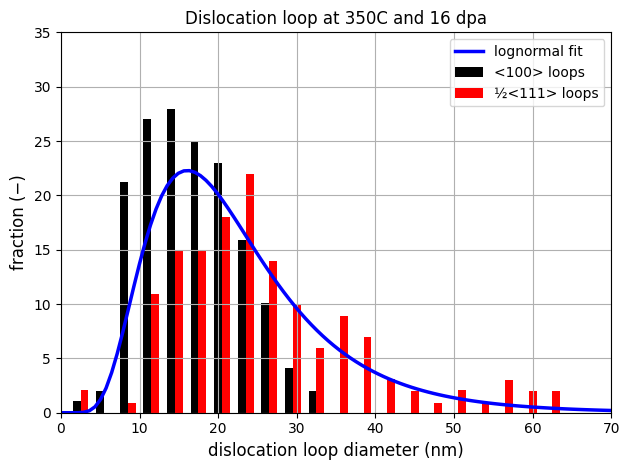

In [8]:
plt.bar(datasets["350C_16dpa_100"]["Diameter"]-1, datasets["350C_16dpa_100"]["Fraction"], width=1, color='black', label='<100> loops')
plt.bar(datasets["350C_16dpa_111"]["Diameter"], datasets["350C_16dpa_111"]["Fraction"], width=1, color='red', label='½<111> loops')

x_all = np.concatenate([datasets["350C_16dpa_100"]["Diameter"], datasets["350C_16dpa_111"]["Diameter"]])
y_all = np.concatenate([datasets["350C_16dpa_100"]["Fraction"], datasets["350C_16dpa_111"]["Fraction"]])

mask = y_all > 0
x_all = x_all[mask]
y_all = y_all[mask]

p0 = [max(y_all), np.mean(x_all), np.std(x_all)] # Initial guesses: A, mean, std
popt, pcov = curve_fit(fit_lognormal, x_all, y_all, p0=p0, maxfev=10000)
A_fit, mean_fit, std_fit = popt

xfit = np.linspace(0.1, 70, 100)
yfit = fit_lognormal(xfit, *popt)

sigma = np.sqrt(np.log(1 + (std_fit / mean_fit)**2))
mu = np.log(mean_fit) - 0.5 * sigma**2
mean_theoretical = np.exp(mu + 0.5 * sigma**2)
var_theoretical  = (np.exp(sigma**2) - 1) * np.exp(2*mu + sigma**2)
std_theoretical  = np.sqrt(var_theoretical)
skew_theoretical = (np.exp(sigma**2) + 2) * np.sqrt(np.exp(sigma**2) - 1)
kurt_theoretical = np.exp(4*sigma**2) + 2*np.exp(3*sigma**2) + 3*np.exp(2*sigma**2)

print(f"Lognormal fit parameters:")
print(f"  A = {A_fit:.3f}")
print(f"  mean = {mean_fit:.2f} nm")
print(f"  std  = {std_fit:.2f} nm")
print(f"\nFitted lognormal moments:")
print(f"  Mean     = {mean_theoretical:.2f} nm")
print(f"  Variance = {var_theoretical:.2f} nm^2  (Std = {std_theoretical:.2f} nm)")
print(f"  Skewness = {skew_theoretical:.3f}")
print(f"  Kurtosis = {kurt_theoretical:.3f}")
plt.plot(xfit, fit_lognormal(xfit, *popt), lw=2.5, label='lognormal fit', c='b')

plt.xlabel('dislocation loop diameter (nm)', fontsize=12)
plt.ylabel('fraction (−)', fontsize=12)
plt.title("Dislocation loop at 350C and 16 dpa")
plt.xlim(0, 70)
plt.ylim(0, 35)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Schaeublin et al. - 2002 - Microstructure of irradiated ferriticmartensitic steels in relation to mechanical properties

|     Temperature    | Dose (dpa) | Dominant Loop Type|   Fraction (〈100〉: ½〈111〉)   | Notes|
| :---------: | :--------: | :-------------------------------------- | :-----------------------------------: | 
|**250 °C**|0.5–1| Mainly ½〈111〉 loops (“black spots”)     |**0.2 : 0.8**| Early damage consists of small, mobile ½〈111〉 loops; low defect density.|
|**300 °C**|8.8–9.2| 〈100〉 loops dominate, few ½〈111〉 remain |**0.8 : 0.2** | Loops homogeneously distributed; g = {200} shows strong 〈100〉 contrast; few large ½〈111〉 loops visible. |



**Transition trend**  Gradual ½〈111〉 → 〈100〉 conversion  Linear/logistic trend between 0.2→0.8 | Driven by loop–loop interactions: ½[111] + ½[1̄11] → [100].              
**> 10 dpa / > 300 °C**〈100〉 loops dominate 〈100〉 loops become immobile sinks; few residual ½〈111〉 loops persist.                                   |


#### Chen - 2013 - IRRADIATION EFFECTS OF HT-9 MARTENSITIC STEEL

| Reference / Condition| Temperature (°C) | Dose (dpa) | Loop Type Behavior|〈100〉:½〈111〉 Fraction |
| :------------------------------------------------------ |:----------------:| :--------: | :------------------------ | :----------------------: |
| **Hashimoto et al. (2002)** (High Flux Isotope Reactor) |       400        | 7.4| 〈100〉 loops density ≈ 1 × 10²² m⁻³ ≈ 3× higher than ½〈111〉 loops                     |           **0.75 : 0.25**          |
| **Sencer et al. (2003)** (FFTF – 155 dpa)               |       443        |     155    |loops predominantly 〈100〉 (5 × 10²⁰ m⁻³, 18 nm)  |     **0.85 : 0.15 (for loops)**    |
| **Kai & Kulcinski (14 MeV Ni ions)**                    |      ≤ 600       |      —     | Most loops are interstitial 〈100〉; recovery stage appears > 600 °C                   | **→ 1.0 at high T**, then recovery |


#### Boulanger and Serruys - 2009 - Dislocation loops in Eurofer and a Fe–Cr alloy irradiated by ions at 350 and 550°C at 3dpa Effect of dose rate

Lognormal fit parameters:
  A = 193.015
  mean = 9.39 nm
  std  = 4.90 nm

Fitted lognormal moments:
  Mean     = 9.39 nm
  Variance = 24.02 nm^2  (Std = 4.90 nm)
  Skewness = 1.708
  Kurtosis = 11.602


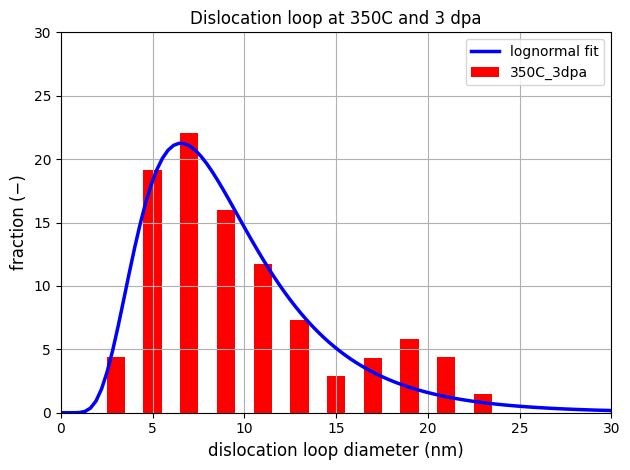

In [9]:
plt.bar(datasets["350C_3dpa"]["Diameter"], datasets["350C_3dpa"]["Fraction"], width=1, color='red', label='350C_3dpa')

x_all = np.array(datasets["350C_3dpa"]["Diameter"])
y_all = np.array(datasets["350C_3dpa"]["Fraction"])

mask = y_all > 0
x_all = x_all[mask]
y_all = y_all[mask]

p0 = [max(y_all), np.mean(x_all), np.std(x_all)] # Initial guesses: A, mean, std
popt, pcov = curve_fit(fit_lognormal, x_all, y_all, p0=p0, maxfev=10000)
A_fit, mean_fit, std_fit = popt

xfit = np.linspace(0.1, 30, 100)
yfit = fit_lognormal(xfit, *popt)

sigma = np.sqrt(np.log(1 + (std_fit / mean_fit)**2))
mu = np.log(mean_fit) - 0.5 * sigma**2
mean_theoretical = np.exp(mu + 0.5 * sigma**2)
var_theoretical  = (np.exp(sigma**2) - 1) * np.exp(2*mu + sigma**2)
std_theoretical  = np.sqrt(var_theoretical)
skew_theoretical = (np.exp(sigma**2) + 2) * np.sqrt(np.exp(sigma**2) - 1)
kurt_theoretical = np.exp(4*sigma**2) + 2*np.exp(3*sigma**2) + 3*np.exp(2*sigma**2)

print(f"Lognormal fit parameters:")
print(f"  A = {A_fit:.3f}")
print(f"  mean = {mean_fit:.2f} nm")
print(f"  std  = {std_fit:.2f} nm")
print(f"\nFitted lognormal moments:")
print(f"  Mean     = {mean_theoretical:.2f} nm")
print(f"  Variance = {var_theoretical:.2f} nm^2  (Std = {std_theoretical:.2f} nm)")
print(f"  Skewness = {skew_theoretical:.3f}")
print(f"  Kurtosis = {kurt_theoretical:.3f}")
plt.plot(xfit, fit_lognormal(xfit, *popt), lw=2.5, label='lognormal fit', c='b')

plt.xlabel('dislocation loop diameter (nm)', fontsize=12)
plt.ylabel('fraction (−)', fontsize=12)
plt.title("Dislocation loop at 350C and 3 dpa")
plt.xlim(0, 30)
plt.ylim(0, 30)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

[ 0.00753439  0.50764925 -2.88374273]


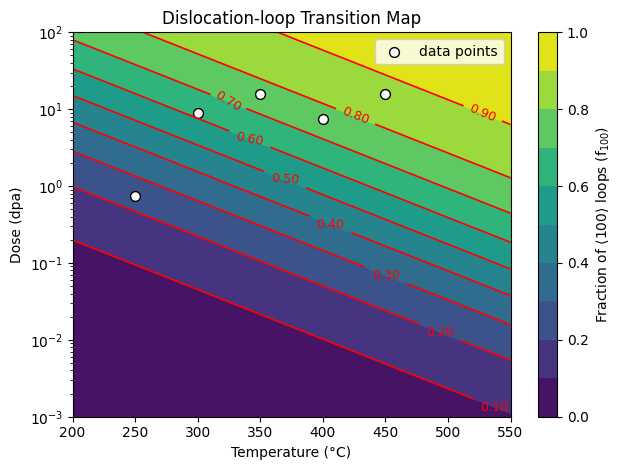


**Data sources:**
- [Boulanger and Serruys - 2009 - Dislocation loops in Eurofer and a Fe–Cr alloy irradiated by ions at 350 and 550°C at 3dpa Effect of dose rate](https://drive.google.com/file/d/1ygp2hFfx7hQq7NeUctmj77fYqVUlyiuP/view?usp=drive_link)
- [Chen2013-IRRADIATION EFFECTS OF HT-9 MARTENSITIC STEEL](https://drive.google.com/file/d/1A1tQf9G3JRVsEkEiJZ9L8HBvh0DQuiuP/view?usp=drive_link)
- [Dethloff et al. - 2016 - Microstructural defects in EUROFER 97 after different neutron irradiation conditions](https://drive.google.com/file/d/1ugHZrr82WKFZdadMXntUsoxFKfsGqORD/view?usp=drive_link)
- [Klimenkov et al. - 2017 - Effect of irradiation temperature on microstructure of ferritic-martensitic ODS steel](https://drive.google.com/file/d/13ksTwQyniAPry8-RZ39TCJuE1flkYZhd/view?usp=drive_link)
- [Schaublin2002-Microstructure of irradiated ferritic-martensitic steels](https://drive.google.com/file/d/1CP8uXxbFvO-XMIwmRhE2w8ifhHX5zdmw/view?usp=drive_link)
- [Was2025-International round robin on ion irradiation of alloy T91 and comparison](https://drive.google.com/file/d/1RprAn4ox_7RUi7ZAMrxXkjYyqyhHhnfQ/view?usp=drive_link)


In [10]:
points = [
    (250.0, 0.75, 0.20),   # Schaublin 2002, 0.5–1 dpa
    (300.0, 9.0,  0.80),   # Schaublin 2002, 8.8–9.2 dpa
    (350.0, 16.0, 0.50),   # Klimenkov 2017, 16 dpa
    (400.0, 7.4,  0.75),   # Chen 2013, 7.4 dpa
    (450.0, 16.0, 1.00),   # Klimenkov 2017, 16 dpa
]

T_pts = np.array([p[0] for p in points])
d_pts = np.array([p[1] for p in points])
f100_pts = np.array([p[2] for p in points])

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def residuals(params):
    a, b, c = params
    z = a*T_pts + b*np.log(d_pts) + c
    return sigmoid(z) - f100_pts

theta0 = [0.01, 0.5, -5.0]
res = least_squares(residuals, theta0, max_nfev=20000)
print(res.x)
a, b, c = res.x

T_range = np.linspace(200, 550, 300)
D_range = np.logspace(np.log10(0.001), np.log10(100), 300)
TT, DD = np.meshgrid(T_range, D_range)
ZZ = sigmoid(a*TT + b*np.log(DD) + c)


plt.figure()
levels = np.linspace(0, 1, 11)
cf = plt.contourf(TT, DD, ZZ, levels=levels, cmap='viridis')
plt.colorbar(cf, label='Fraction of ⟨100⟩ loops ($f_{100}$)')
cs = plt.contour(TT, DD, ZZ, levels=np.arange(0.1, 1.0, 0.1),colors='red', linewidths=1.2)
plt.clabel(cs, fmt='%0.2f', colors='red', fontsize=9, inline=True)
plt.scatter(T_pts, d_pts, s=50, color='white', edgecolors='black', label='data points')

plt.yscale('log')
plt.xlabel('Temperature (°C)')
plt.ylabel('Dose (dpa)')
plt.title('Dislocation-loop Transition Map')
plt.legend()
plt.tight_layout()
plt.show()

display(Markdown("""
**Data sources:**
- [Boulanger and Serruys - 2009 - Dislocation loops in Eurofer and a Fe–Cr alloy irradiated by ions at 350 and 550°C at 3dpa Effect of dose rate](https://drive.google.com/file/d/1ygp2hFfx7hQq7NeUctmj77fYqVUlyiuP/view?usp=drive_link)
- [Chen2013-IRRADIATION EFFECTS OF HT-9 MARTENSITIC STEEL](https://drive.google.com/file/d/1A1tQf9G3JRVsEkEiJZ9L8HBvh0DQuiuP/view?usp=drive_link)
- [Dethloff et al. - 2016 - Microstructural defects in EUROFER 97 after different neutron irradiation conditions](https://drive.google.com/file/d/1ugHZrr82WKFZdadMXntUsoxFKfsGqORD/view?usp=drive_link)
- [Klimenkov et al. - 2017 - Effect of irradiation temperature on microstructure of ferritic-martensitic ODS steel](https://drive.google.com/file/d/13ksTwQyniAPry8-RZ39TCJuE1flkYZhd/view?usp=drive_link)
- [Schaublin2002-Microstructure of irradiated ferritic-martensitic steels](https://drive.google.com/file/d/1CP8uXxbFvO-XMIwmRhE2w8ifhHX5zdmw/view?usp=drive_link)
- [Was2025-International round robin on ion irradiation of alloy T91 and comparison](https://drive.google.com/file/d/1RprAn4ox_7RUi7ZAMrxXkjYyqyhHhnfQ/view?usp=drive_link)
"""))

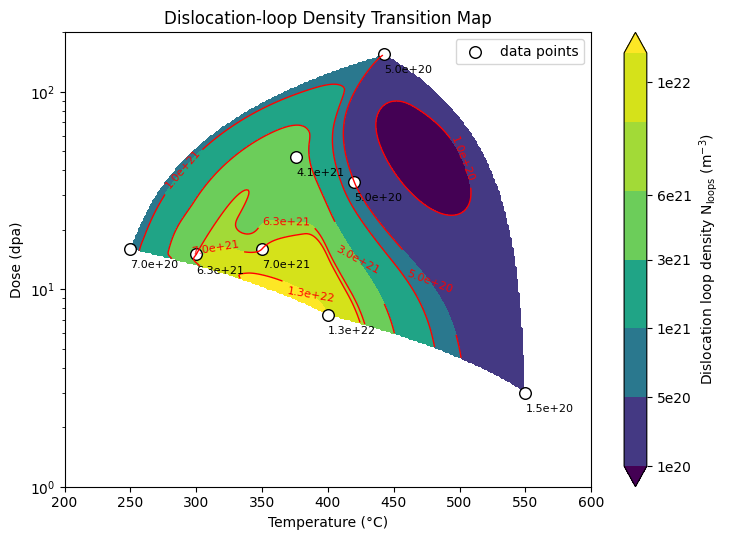


**Data sources:**
- [Boulanger and Serruys - 2009 - Dislocation loops in Eurofer and a Fe–Cr alloy irradiated by ions at 350 and 550°C at 3dpa Effect of dose rate](https://drive.google.com/file/d/1ygp2hFfx7hQq7NeUctmj77fYqVUlyiuP/view?usp=drive_link)
- [Chen2013-IRRADIATION EFFECTS OF HT-9 MARTENSITIC STEEL](https://drive.google.com/file/d/1A1tQf9G3JRVsEkEiJZ9L8HBvh0DQuiuP/view?usp=drive_link)
- [Dethloff et al. - 2016 - Microstructural defects in EUROFER 97 after different neutron irradiation conditions](https://drive.google.com/file/d/1ugHZrr82WKFZdadMXntUsoxFKfsGqORD/view?usp=drive_link)
- [Klimenkov et al. - 2017 - Effect of irradiation temperature on microstructure of ferritic-martensitic ODS steel](https://drive.google.com/file/d/13ksTwQyniAPry8-RZ39TCJuE1flkYZhd/view?usp=drive_link)
- [Schaublin2002-Microstructure of irradiated ferritic-martensitic steels](https://drive.google.com/file/d/1CP8uXxbFvO-XMIwmRhE2w8ifhHX5zdmw/view?usp=drive_link)
- [Was2025-International round robin on ion irradiation of alloy T91 and comparison](https://drive.google.com/file/d/1RprAn4ox_7RUi7ZAMrxXkjYyqyhHhnfQ/view?usp=drive_link)


In [11]:
points = [
    (300, 15, 6.3e21),
    (250, 16, 7e20),
    (350, 16, 7e21),
    (400, 7.4, 1.3e22),
    (420, 35, 5e20),
    (443, 155, 5e20),
    (550, 3, 1.5e20),
    (376, 47, 4.12e21),
]

T, dose, val = zip(*points)
T, dose, val = np.array(T), np.array(dose), np.array(val)

Ti = np.linspace(200, 550, 300)
Di = np.logspace(0, np.log10(200), 300)  # dose from 1 → 150 (log scale)
Ti_grid, Di_grid = np.meshgrid(Ti, Di)
Vi = griddata((T, dose), np.log10(val), (Ti_grid, Di_grid), method='cubic')
levels = np.log10([1e20, 5e20, 1e21, 3e21, 6.3e21, 7e21, 1.3e22])

plt.figure(figsize=(7.5, 5.5))
cf = plt.contourf(Ti_grid, Di_grid, Vi, levels=levels, cmap='viridis', extend='both')
cb = plt.colorbar(cf)
cb.set_label(r'Dislocation loop density $N_{\mathrm{loops}}\ (m^{-3})$', fontsize=10)
cb.set_ticks(np.log10([1e20, 5e20, 1e21, 3e21, 6e21, 1e22]))
cb.set_ticklabels(['1e20', '5e20', '1e21', '3e21', '6e21', '1e22'])
cs = plt.contour(Ti_grid, Di_grid, Vi, levels=levels, colors='red', linewidths=1)
plt.clabel(cs, fmt=lambda v: f"{10**v:.1e}", colors='red', fontsize=8)

plt.scatter(T, dose, s=70, facecolor='white', edgecolor='black', label='data points')
for t, d, v in points:
    plt.text(t, d* 0.8, f"{v:.1e}", fontsize=8, color='black', weight='bold')

plt.yscale('log')
plt.ylim(1, 200)
plt.xlim(200, 600)
plt.xlabel("Temperature (°C)")
plt.ylabel("Dose (dpa)")
plt.title("Dislocation-loop Density Transition Map")
plt.legend()
plt.tight_layout()
plt.show()

display(Markdown("""
**Data sources:**
- [Boulanger and Serruys - 2009 - Dislocation loops in Eurofer and a Fe–Cr alloy irradiated by ions at 350 and 550°C at 3dpa Effect of dose rate](https://drive.google.com/file/d/1ygp2hFfx7hQq7NeUctmj77fYqVUlyiuP/view?usp=drive_link)
- [Chen2013-IRRADIATION EFFECTS OF HT-9 MARTENSITIC STEEL](https://drive.google.com/file/d/1A1tQf9G3JRVsEkEiJZ9L8HBvh0DQuiuP/view?usp=drive_link)
- [Dethloff et al. - 2016 - Microstructural defects in EUROFER 97 after different neutron irradiation conditions](https://drive.google.com/file/d/1ugHZrr82WKFZdadMXntUsoxFKfsGqORD/view?usp=drive_link)
- [Klimenkov et al. - 2017 - Effect of irradiation temperature on microstructure of ferritic-martensitic ODS steel](https://drive.google.com/file/d/13ksTwQyniAPry8-RZ39TCJuE1flkYZhd/view?usp=drive_link)
- [Schaublin2002-Microstructure of irradiated ferritic-martensitic steels](https://drive.google.com/file/d/1CP8uXxbFvO-XMIwmRhE2w8ifhHX5zdmw/view?usp=drive_link)
- [Was2025-International round robin on ion irradiation of alloy T91 and comparison](https://drive.google.com/file/d/1RprAn4ox_7RUi7ZAMrxXkjYyqyhHhnfQ/view?usp=drive_link)
"""))

N0=22.226, Tc=365.7°C, σT=91.1, Dc=1.00 dpa, σD=3.07


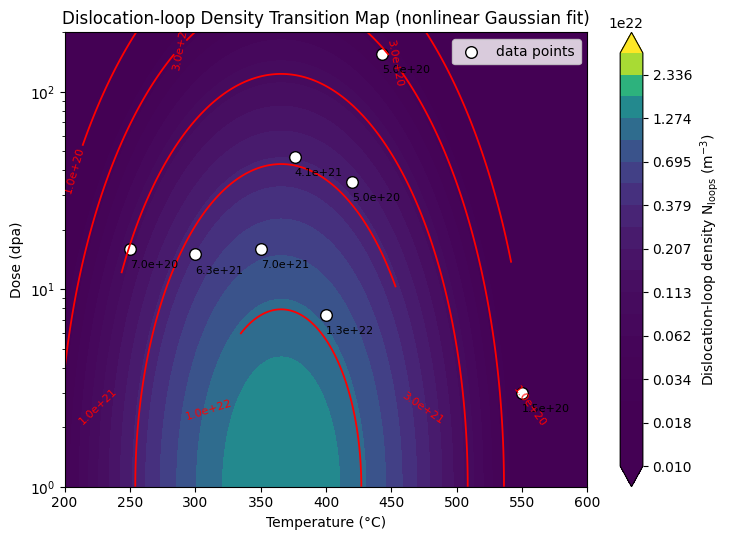


**Data sources:**
- [Boulanger and Serruys - 2009 - Dislocation loops in Eurofer and a Fe–Cr alloy irradiated by ions at 350 and 550°C at 3dpa Effect of dose rate](https://drive.google.com/file/d/1ygp2hFfx7hQq7NeUctmj77fYqVUlyiuP/view?usp=drive_link)
- [Chen2013-IRRADIATION EFFECTS OF HT-9 MARTENSITIC STEEL](https://drive.google.com/file/d/1A1tQf9G3JRVsEkEiJZ9L8HBvh0DQuiuP/view?usp=drive_link)
- [Dethloff et al. - 2016 - Microstructural defects in EUROFER 97 after different neutron irradiation conditions](https://drive.google.com/file/d/1ugHZrr82WKFZdadMXntUsoxFKfsGqORD/view?usp=drive_link)
- [Klimenkov et al. - 2017 - Effect of irradiation temperature on microstructure of ferritic-martensitic ODS steel](https://drive.google.com/file/d/13ksTwQyniAPry8-RZ39TCJuE1flkYZhd/view?usp=drive_link)
- [Schaublin2002-Microstructure of irradiated ferritic-martensitic steels](https://drive.google.com/file/d/1CP8uXxbFvO-XMIwmRhE2w8ifhHX5zdmw/view?usp=drive_link)
- [Was2025-International round robin on ion irradiation of alloy T91 and comparison](https://drive.google.com/file/d/1RprAn4ox_7RUi7ZAMrxXkjYyqyhHhnfQ/view?usp=drive_link)


In [12]:
points = [
    (300, 15, 6.3e21),
    (250, 16, 7e20),
    (350, 16, 7e21),
    (400, 7.4, 1.3e22),
    (420, 35, 5e20),
    (443, 155, 5e20),
    (550, 3, 1.5e20),
    (376, 47, 4.12e21),
]

T_pts = np.array([p[0] for p in points])
D_pts = np.array([p[1] for p in points])
N_pts = np.array([p[2] for p in points])

# --- 2D Gaussian nonlinear model ---
def model(params, T, D):
    N0, Tc, sigT, Dc, sigD = params
    return (N0 -
            ((T - Tc)**2) / (2 * sigT**2) -
            ((np.log(D) - np.log(Dc))**2) / (2 * sigD**2))

def residuals(params):
    return np.log10(N_pts) - model(params, T_pts, D_pts)

# --- initial guess (approximate peak around 375°C, 10 dpa) ---
theta0 = [22, 375, 80, 10, 1.2]
res = least_squares(
    residuals,
    theta0,
    bounds=([20, 200, 10, 1, 0.1],   # lower bounds: N0, Tc, sigT, Dc, sigD
            [30, 550, 300, 200, 5]), # upper bounds
)

N0, Tc, sigT, Dc, sigD = res.x
print(f"N0={N0:.3f}, Tc={Tc:.1f}°C, σT={sigT:.1f}, Dc={Dc:.2f} dpa, σD={sigD:.2f}")

# --- contour map ---
T_range = np.linspace(200, 600, 400)
D_range = np.logspace(0, np.log10(200), 400)
TT, DD = np.meshgrid(T_range, D_range)
logN_pred = model(res.x, TT, DD)
N_pred = 10**logN_pred

plt.figure(figsize=(7.5, 5.5))
levels = np.logspace(20, 22.5, 20)
cf = plt.contourf(TT, DD, N_pred, levels=levels, cmap='viridis', extend='both')
cb = plt.colorbar(cf)
cb.set_label(r'Dislocation-loop density $N_{\mathrm{loops}}\ (m^{-3})$')
cs = plt.contour(TT, DD, N_pred,
                 levels=[1e20, 3e20, 1e21, 3e21, 1e22],
                 colors='red', linewidths=1.3)
plt.clabel(cs, fmt='%.1e', colors='red', fontsize=8)

plt.scatter(T_pts, D_pts, s=70, facecolor='white', edgecolor='black', label='data points')
for t, d, v in points:
    plt.text(t, d* 0.8, f"{v:.1e}", fontsize=8, color='black', weight='bold')

plt.yscale('log')
plt.ylim(1, 200)
plt.xlim(200, 600)
plt.xlabel("Temperature (°C)")
plt.ylabel("Dose (dpa)")
plt.title("Dislocation-loop Density Transition Map (nonlinear Gaussian fit)")
plt.legend()
plt.tight_layout()
plt.show()

display(Markdown("""
**Data sources:**
- [Boulanger and Serruys - 2009 - Dislocation loops in Eurofer and a Fe–Cr alloy irradiated by ions at 350 and 550°C at 3dpa Effect of dose rate](https://drive.google.com/file/d/1ygp2hFfx7hQq7NeUctmj77fYqVUlyiuP/view?usp=drive_link)
- [Chen2013-IRRADIATION EFFECTS OF HT-9 MARTENSITIC STEEL](https://drive.google.com/file/d/1A1tQf9G3JRVsEkEiJZ9L8HBvh0DQuiuP/view?usp=drive_link)
- [Dethloff et al. - 2016 - Microstructural defects in EUROFER 97 after different neutron irradiation conditions](https://drive.google.com/file/d/1ugHZrr82WKFZdadMXntUsoxFKfsGqORD/view?usp=drive_link)
- [Klimenkov et al. - 2017 - Effect of irradiation temperature on microstructure of ferritic-martensitic ODS steel](https://drive.google.com/file/d/13ksTwQyniAPry8-RZ39TCJuE1flkYZhd/view?usp=drive_link)
- [Schaublin2002-Microstructure of irradiated ferritic-martensitic steels](https://drive.google.com/file/d/1CP8uXxbFvO-XMIwmRhE2w8ifhHX5zdmw/view?usp=drive_link)
- [Was2025-International round robin on ion irradiation of alloy T91 and comparison](https://drive.google.com/file/d/1RprAn4ox_7RUi7ZAMrxXkjYyqyhHhnfQ/view?usp=drive_link)
"""))

a=7.866e-03, b=-3.927e-01, c=9.852e-04, d=-2.919e-06, e=2.558e-02, f=-1.370e+00


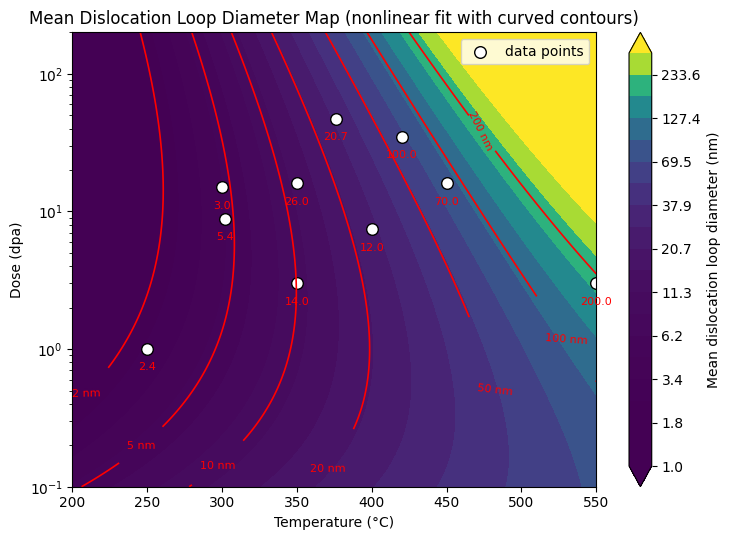


**Data sources:**
- [Boulanger and Serruys - 2009 - Dislocation loops in Eurofer and a Fe–Cr alloy irradiated by ions at 350 and 550°C at 3dpa Effect of dose rate](https://drive.google.com/file/d/1ygp2hFfx7hQq7NeUctmj77fYqVUlyiuP/view?usp=drive_link)
- [Chen2013-IRRADIATION EFFECTS OF HT-9 MARTENSITIC STEEL](https://drive.google.com/file/d/1A1tQf9G3JRVsEkEiJZ9L8HBvh0DQuiuP/view?usp=drive_link)
- [Dethloff et al. - 2016 - Microstructural defects in EUROFER 97 after different neutron irradiation conditions](https://drive.google.com/file/d/1ugHZrr82WKFZdadMXntUsoxFKfsGqORD/view?usp=drive_link)
- [Klimenkov et al. - 2017 - Effect of irradiation temperature on microstructure of ferritic-martensitic ODS steel](https://drive.google.com/file/d/13ksTwQyniAPry8-RZ39TCJuE1flkYZhd/view?usp=drive_link)
- [Schaublin2002-Microstructure of irradiated ferritic-martensitic steels](https://drive.google.com/file/d/1CP8uXxbFvO-XMIwmRhE2w8ifhHX5zdmw/view?usp=drive_link)
- [Was2025-International round robin on ion irradiation of alloy T91 and comparison](https://drive.google.com/file/d/1RprAn4ox_7RUi7ZAMrxXkjYyqyhHhnfQ/view?usp=drive_link)


In [13]:
points = [
    (300, 15, 3),
    (350, 16, 26),
    (450, 16, 70),
    (250, 1, 2.4),
    (302, 8.8, 5.4),
    (400, 7.4, 12),
    (420, 35, 100),
    (350, 3 , 14),
    (550, 3, 200),
    (376, 47, 20.7)
]

T_pts = np.array([p[0] for p in points])
D_pts = np.array([p[1] for p in points])
d_pts = np.array([p[2] for p in points])

# --- nonlinear model ---
# log10(d) = a*T + b*ln(D) + c*T*ln(D) + d*T^2 + e*(ln D)^2 + f
def residuals(params):
    a, b, c, d, e, f = params
    z = (a*T_pts +
         b*np.log(D_pts) +
         c*T_pts*np.log(D_pts) +
         d*T_pts**2 +
         e*(np.log(D_pts))**2 +
         f)
    return np.log10(d_pts) - z

# initial guess
theta0 = [0.001, 0.1, 0.0001, -1e-6, 0.01, 0]
res = least_squares(residuals, theta0, max_nfev=20000)
a, b, c, d, e, f = res.x
print(f"a={a:.3e}, b={b:.3e}, c={c:.3e}, d={d:.3e}, e={e:.3e}, f={f:.3e}")

# grid for prediction
T_range = np.linspace(200, 550, 300)
D_range = np.logspace(np.log10(0.1), np.log10(200), 300)
TT, DD = np.meshgrid(T_range, D_range)

logD_pred = (a*TT + b*np.log(DD) +
             c*TT*np.log(DD) +
             d*TT**2 +
             e*(np.log(DD))**2 +
             f)
D_pred = 10**logD_pred

# --- plot ---
plt.figure(figsize=(7.5, 5.5))
levels = np.logspace(0, 2.5, 20)
cf = plt.contourf(TT, DD, D_pred, levels=levels, cmap='viridis', extend='both')
cb = plt.colorbar(cf)
cb.set_label('Mean dislocation loop diameter (nm)')

cs = plt.contour(TT, DD, D_pred,
                 levels=[2, 5, 10, 20, 50, 100, 200],
                 colors='red', linewidths=1.2)
plt.clabel(cs, fmt='%g nm', colors='red', fontsize=8)
plt.scatter(T_pts, D_pts, s=70, facecolor='white', edgecolor='black', label='data points')
for t, d, v in points:
    plt.text(t, d*0.8, f"{v:.1f}", color='red', fontsize=8, ha='center', va='top')

plt.yscale('log')
plt.ylim(0.1, 200)
plt.xlim(200, 550)
plt.xlabel("Temperature (°C)")
plt.ylabel("Dose (dpa)")
plt.title("Mean Dislocation Loop Diameter Map (nonlinear fit with curved contours)")
plt.legend()
plt.tight_layout()
plt.show()

display(Markdown("""
**Data sources:**
- [Boulanger and Serruys - 2009 - Dislocation loops in Eurofer and a Fe–Cr alloy irradiated by ions at 350 and 550°C at 3dpa Effect of dose rate](https://drive.google.com/file/d/1ygp2hFfx7hQq7NeUctmj77fYqVUlyiuP/view?usp=drive_link)
- [Chen2013-IRRADIATION EFFECTS OF HT-9 MARTENSITIC STEEL](https://drive.google.com/file/d/1A1tQf9G3JRVsEkEiJZ9L8HBvh0DQuiuP/view?usp=drive_link)
- [Dethloff et al. - 2016 - Microstructural defects in EUROFER 97 after different neutron irradiation conditions](https://drive.google.com/file/d/1ugHZrr82WKFZdadMXntUsoxFKfsGqORD/view?usp=drive_link)
- [Klimenkov et al. - 2017 - Effect of irradiation temperature on microstructure of ferritic-martensitic ODS steel](https://drive.google.com/file/d/13ksTwQyniAPry8-RZ39TCJuE1flkYZhd/view?usp=drive_link)
- [Schaublin2002-Microstructure of irradiated ferritic-martensitic steels](https://drive.google.com/file/d/1CP8uXxbFvO-XMIwmRhE2w8ifhHX5zdmw/view?usp=drive_link)
- [Was2025-International round robin on ion irradiation of alloy T91 and comparison](https://drive.google.com/file/d/1RprAn4ox_7RUi7ZAMrxXkjYyqyhHhnfQ/view?usp=drive_link)
"""))

a=-5.060e-02, b=9.958e-02, c=1.613e-02, d=2.264e-05, e=1.010e-02, f=-3.195e-04


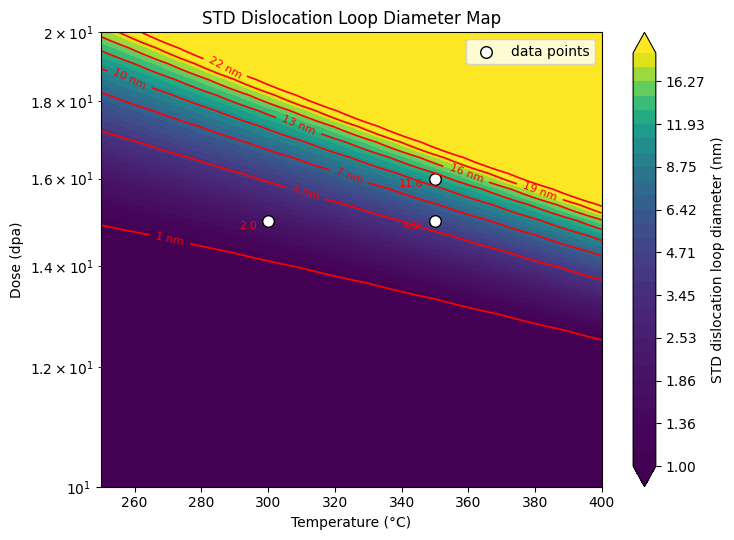


**Data sources:**
- [Boulanger and Serruys - 2009 - Dislocation loops in Eurofer and a Fe–Cr alloy irradiated by ions at 350 and 550°C at 3dpa Effect of dose rate](https://drive.google.com/file/d/1ygp2hFfx7hQq7NeUctmj77fYqVUlyiuP/view?usp=drive_link)
- [Chen2013-IRRADIATION EFFECTS OF HT-9 MARTENSITIC STEEL](https://drive.google.com/file/d/1A1tQf9G3JRVsEkEiJZ9L8HBvh0DQuiuP/view?usp=drive_link)
- [Dethloff et al. - 2016 - Microstructural defects in EUROFER 97 after different neutron irradiation conditions](https://drive.google.com/file/d/1ugHZrr82WKFZdadMXntUsoxFKfsGqORD/view?usp=drive_link)
- [Klimenkov et al. - 2017 - Effect of irradiation temperature on microstructure of ferritic-martensitic ODS steel](https://drive.google.com/file/d/13ksTwQyniAPry8-RZ39TCJuE1flkYZhd/view?usp=drive_link)
- [Schaublin2002-Microstructure of irradiated ferritic-martensitic steels](https://drive.google.com/file/d/1CP8uXxbFvO-XMIwmRhE2w8ifhHX5zdmw/view?usp=drive_link)
- [Was2025-International round robin on ion irradiation of alloy T91 and comparison](https://drive.google.com/file/d/1RprAn4ox_7RUi7ZAMrxXkjYyqyhHhnfQ/view?usp=drive_link)


In [14]:
points = [
    (350, 15, 4.9),
    (350, 16, 11.6),
    (300, 15, 2),
]

T_pts = np.array([p[0] for p in points])
D_pts = np.array([p[1] for p in points])
d_pts = np.array([p[2] for p in points])

# --- nonlinear model ---
# log10(d) = a*T + b*ln(D) + c*T*ln(D) + d*T^2 + e*(ln D)^2 + f
def residuals(params):
    a, b, c, d, e, f = params
    z = (a*T_pts +
         b*np.log(D_pts) +
         c*T_pts*np.log(D_pts) +
         d*T_pts**2 +
         e*(np.log(D_pts))**2 +
         f)
    return np.log10(d_pts) - z

# initial guess
theta0 = [0.001, 0.1, 0.0001, -1e-6, 0.01, 0]
res = least_squares(residuals, theta0, max_nfev=20000)
a, b, c, d, e, f = res.x
print(f"a={a:.3e}, b={b:.3e}, c={c:.3e}, d={d:.3e}, e={e:.3e}, f={f:.3e}")

# grid for prediction
T_range = np.linspace(250, 400, 300)
D_range = np.logspace(np.log10(10), np.log10(20), 30)
TT, DD = np.meshgrid(T_range, D_range)

logD_pred = (a*TT + b*np.log(DD) +
             c*TT*np.log(DD) +
             d*TT**2 +
             e*(np.log(DD))**2 +
             f)
D_pred = 10**logD_pred

# --- plot ---
plt.figure(figsize=(7.5, 5.5))
levels = np.logspace(np.log10(1), np.log10(20), 30)
cf = plt.contourf(TT, DD, D_pred, levels=levels, cmap='viridis', extend='both')
cb = plt.colorbar(cf)
cb.set_label('STD dislocation loop diameter (nm)')

cs = plt.contour(TT, DD, D_pred,
                 levels=range(1,25,3),
                 colors='red', linewidths=1.2)
plt.clabel(cs, fmt='%g nm', colors='red', fontsize=8)
plt.scatter(T_pts, D_pts, s=70, facecolor='white', edgecolor='black', label='data points')
for t, d, v in points:
    plt.text(t*0.98, d, f"{v:.1f}", color='red', fontsize=8, ha='center', va='top')

plt.yscale('log')
plt.ylim(10, 20)
plt.xlim(250, 400)
plt.xlabel("Temperature (°C)")
plt.ylabel("Dose (dpa)")
plt.title("STD Dislocation Loop Diameter Map")
plt.legend()
plt.tight_layout()
plt.show()

display(Markdown("""
**Data sources:**
- [Boulanger and Serruys - 2009 - Dislocation loops in Eurofer and a Fe–Cr alloy irradiated by ions at 350 and 550°C at 3dpa Effect of dose rate](https://drive.google.com/file/d/1ygp2hFfx7hQq7NeUctmj77fYqVUlyiuP/view?usp=drive_link)
- [Chen2013-IRRADIATION EFFECTS OF HT-9 MARTENSITIC STEEL](https://drive.google.com/file/d/1A1tQf9G3JRVsEkEiJZ9L8HBvh0DQuiuP/view?usp=drive_link)
- [Dethloff et al. - 2016 - Microstructural defects in EUROFER 97 after different neutron irradiation conditions](https://drive.google.com/file/d/1ugHZrr82WKFZdadMXntUsoxFKfsGqORD/view?usp=drive_link)
- [Klimenkov et al. - 2017 - Effect of irradiation temperature on microstructure of ferritic-martensitic ODS steel](https://drive.google.com/file/d/13ksTwQyniAPry8-RZ39TCJuE1flkYZhd/view?usp=drive_link)
- [Schaublin2002-Microstructure of irradiated ferritic-martensitic steels](https://drive.google.com/file/d/1CP8uXxbFvO-XMIwmRhE2w8ifhHX5zdmw/view?usp=drive_link)
- [Was2025-International round robin on ion irradiation of alloy T91 and comparison](https://drive.google.com/file/d/1RprAn4ox_7RUi7ZAMrxXkjYyqyhHhnfQ/view?usp=drive_link)
"""))

### Void and Swelling Character

At an irradiation dose of **15 dpa** and a temperature of **300 °C**,  
the **mean void diameter** is **2.3 nm**, and the **void density** is determined to be $6.3 \times 10^{21}~\text{m}^{-3}$.


Lognormal fit parameters:
  A = 73.376
  mean = 1.72 nm
  std  = 0.70 nm

Fitted lognormal moments:
  Mean     = 1.72 nm
  Variance = 0.49 nm^2  (Std = 0.70 nm)
  Skewness = 1.279
  Kurtosis = 9.041


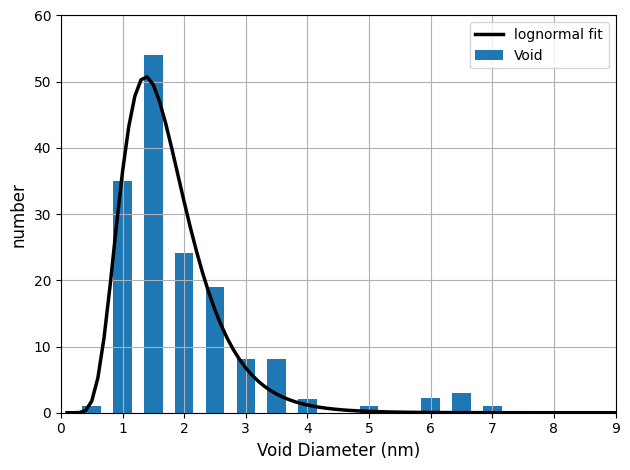

**Data sources:** [Dethloff et al. - 2016 - Microstructural defects in EUROFER 97 after different neutron irradiation conditions](https://drive.google.com/file/d/1ugHZrr82WKFZdadMXntUsoxFKfsGqORD/view?usp=drive_link)

In [15]:
diameter = np.arange(0, 9.5, 0.5)
values = np.array([0, 1.075, 34.935, 54.015, 24.096, 18.990, 8.151, 8.062, 2.060, 0, 1.075, 0, 2.239, 3.046, 0.985, 0, 0, 0, 0])
plt.bar(diameter, values, width=0.3, label='Void')

mask = values > 0
diameter = diameter[mask]
values = values[mask]

p0 = [max(values), np.mean(diameter), np.std(diameter)] # Initial guesses: A, mean, std
popt, pcov = curve_fit(fit_lognormal, diameter, values, p0=p0, maxfev=10000)
A_fit, mean_fit, std_fit = popt

xfit = np.linspace(0.1, 10, 100)
yfit = fit_lognormal(xfit, *popt)

sigma = np.sqrt(np.log(1 + (std_fit / mean_fit)**2))
mu = np.log(mean_fit) - 0.5 * sigma**2
mean_theoretical = np.exp(mu + 0.5 * sigma**2)
var_theoretical  = (np.exp(sigma**2) - 1) * np.exp(2*mu + sigma**2)
std_theoretical  = np.sqrt(var_theoretical)
skew_theoretical = (np.exp(sigma**2) + 2) * np.sqrt(np.exp(sigma**2) - 1)
kurt_theoretical = np.exp(4*sigma**2) + 2*np.exp(3*sigma**2) + 3*np.exp(2*sigma**2)

print(f"Lognormal fit parameters:")
print(f"  A = {A_fit:.3f}")
print(f"  mean = {mean_fit:.2f} nm")
print(f"  std  = {std_fit:.2f} nm")
print(f"\nFitted lognormal moments:")
print(f"  Mean     = {mean_theoretical:.2f} nm")
print(f"  Variance = {var_theoretical:.2f} nm^2  (Std = {std_theoretical:.2f} nm)")
print(f"  Skewness = {skew_theoretical:.3f}")
print(f"  Kurtosis = {kurt_theoretical:.3f}")
plt.plot(xfit, fit_lognormal(xfit, *popt), 'k-', lw=2.5, label='lognormal fit')

plt.xlabel('Void Diameter (nm)', fontsize=12)
plt.ylabel('number', fontsize=12)
plt.xlim(0, 9)
plt.ylim(0, 60)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

display(Markdown("""**Data sources:** [Dethloff et al. - 2016 - Microstructural defects in EUROFER 97 after different neutron irradiation conditions](https://drive.google.com/file/d/1ugHZrr82WKFZdadMXntUsoxFKfsGqORD/view?usp=drive_link)"""))



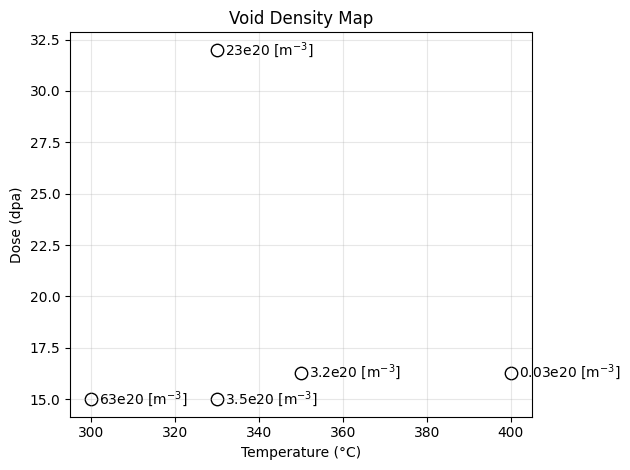

In [16]:
points = [
    (300, 15, 63),
    (350, 16.3, 3.20),
    (400, 16.3, 0.03),
    (330, 15, 3.50),
    (330, 32, 23),
]

T_pts = np.array([p[0] for p in points])
D_pts = np.array([p[1] for p in points])
d_pts = np.array([p[2] for p in points])


plt.scatter(T_pts, D_pts, c='white', edgecolors='black', s=80)

# Add black text labels for the values
for x, y, val in points:
    plt.text(x + 2, y, str(val)+"e20 [$m^{-3}$]", color="black", fontsize=10,
             ha='left', va='center')

plt.ylabel("Dose (dpa)")
plt.xlabel("Temperature (°C)")
plt.title("Void Density Map")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


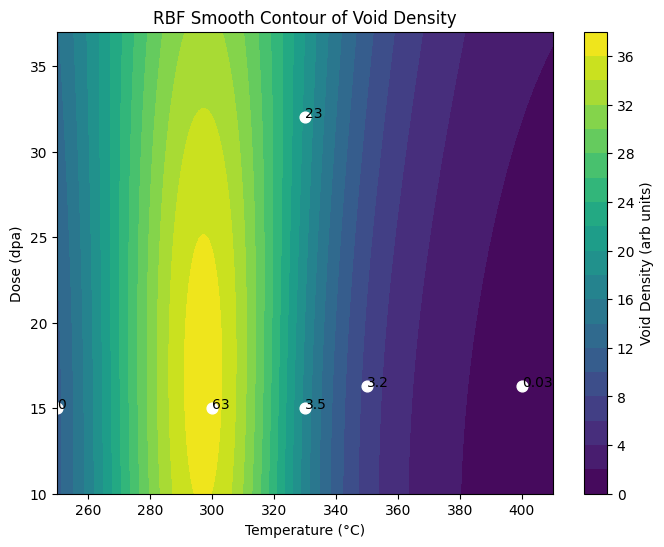

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf

# Your data
points = [
    (250, 15, 0),
    (300, 15, 63),
    (350, 16.3, 3.20),
    (400, 16.3, 0.03),
    (330, 15, 3.50),
    (330, 32, 23),
]

T = np.array([p[0] for p in points])
D = np.array([p[1] for p in points])
Z = np.array([p[2] for p in points])

# RBF interpolation (multiquadric = smooth + best for physical problems)
rbf = Rbf(T, D, Z, function='multiquadric', smooth=1)

# Create contour grid
Ti = np.linspace(250, max(T)+10, 200)
Di = np.linspace(min(D)-5, max(D)+5, 200)
TT, DD = np.meshgrid(Ti, Di)

Zi = rbf(TT, DD)

# Plot
plt.figure(figsize=(8,6))
contour = plt.contourf(TT, DD, Zi, levels=20)
plt.colorbar(contour, label="Void Density (arb units)")

# Plot original data points
plt.scatter(T, D, c='white', s=60)
for i, (t,d,z) in enumerate(points):
    plt.text(t, d, f"{z}", color='black', fontsize=10)

plt.xlabel("Temperature (°C)")
plt.ylabel("Dose (dpa)")
plt.title("RBF Smooth Contour of Void Density")
plt.show()


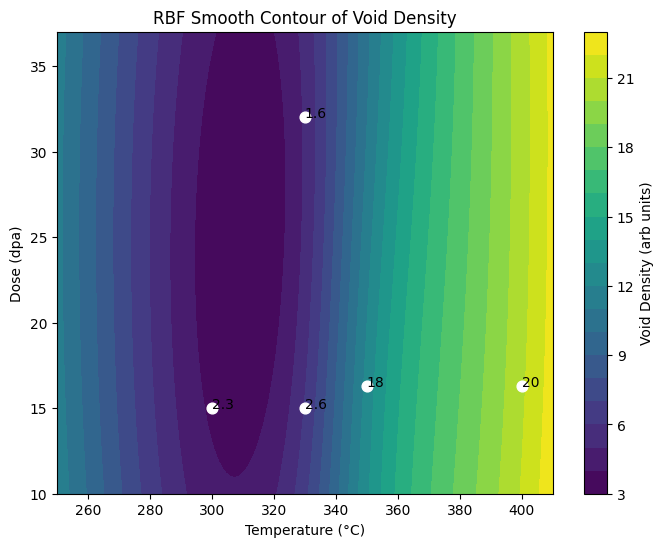

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf

# Your data
points = [
    (300, 15, 2.3),
    (350, 16.3, 18),
    (400, 16.3, 20),
    (330, 15, 2.6),
    (330, 32, 1.6),
]

T = np.array([p[0] for p in points])
D = np.array([p[1] for p in points])
Z = np.array([p[2] for p in points])

# RBF interpolation (multiquadric = smooth + best for physical problems)
rbf = Rbf(T, D, Z, function='multiquadric', smooth=1)

# Create contour grid
Ti = np.linspace(250, max(T)+10, 200)
Di = np.linspace(min(D)-5, max(D)+5, 200)
TT, DD = np.meshgrid(Ti, Di)

Zi = rbf(TT, DD)

# Plot
plt.figure(figsize=(8,6))
contour = plt.contourf(TT, DD, Zi, levels=20)
plt.colorbar(contour, label="Void Density (arb units)")

# Plot original data points
plt.scatter(T, D, c='white', s=60)
for i, (t,d,z) in enumerate(points):
    plt.text(t, d, f"{z}", color='black', fontsize=10)

plt.xlabel("Temperature (°C)")
plt.ylabel("Dose (dpa)")
plt.title("RBF Smooth Contour of Void Density")
plt.show()


## Precipitates

Total precipitate size distribution is described by two log-normal distributed fitting curves of type f (x) = A/(  √  2πσx) exp[−(ln(x/d))2/(2σ2)] with separate mean diameter d, standard deviation σ and curve integral A. Fitting values for the MX (M23C6) size distribution are d = 26 (83) nm, σ = 0.35 (0.45), A = 4.8
Recalculating the continuous fitting curves into discrete histogram values (see [10]) yield  a mean precipitate diameter of 27 nm for MX and 91 nm for M23C6, with a MX number fraction of 46%. With a mean foil thickness of 151 nm, the total precipitate density is determined as 7.9 × 1019 m−3. Thus the precipitate volume fraction after SPICE irradiation in EUROFER 97 can be estimated to 1.08%.

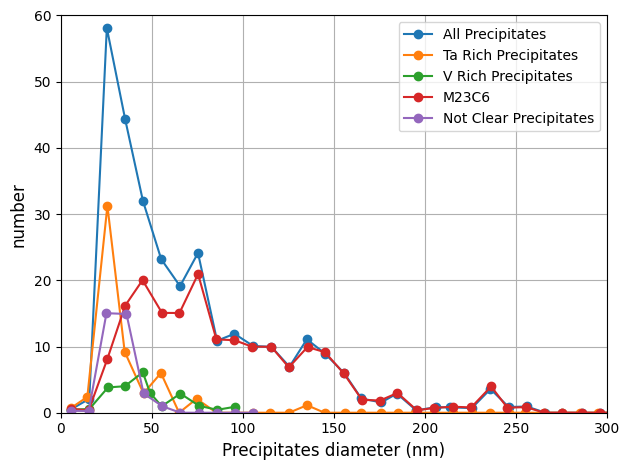

In [19]:
AllPrecipitates = ([5.321, 15.598, 25.230, 35.335, 45.066, 55.111, 65.455, 75.337, 85.790, 95.363, 105.681, 115.623, 125.599, 135.136, 145.102, 155.789, 165.064, 176.077, 184.582, 195.263, 205.909, 214.074, 225.792, 236.053, 246.026, 255.966, 266.273, 275.504, 286.510, 296.096, 306.036], [0.475, 2.100, 58.124, 44.291, 32.005, 23.196, 19.122, 24.130, 10.876, 11.924, 10.071, 9.959, 6.948, 11.087, 8.945, 5.933, 2.150, 1.552, 2.891, 0.362, 0.828, 0.815, 0.699, 3.581, 0.860, 0.940, 0, 0, 0, 0, 0])
TaRichPrecipitates = ([5.319, 14.529, 25.548, 35.040, 45.410, 54.960, 64.964, 74.532, 85.558, 95.854, 105.794, 115.025, 125.322, 135.254, 144.850, 156.213, 164.732, 176.092, 184.967, 194.553, 205.204, 215.500, 226.149, 235.738, 246.033, 254.907, 265.204, 275.144, 285.084, 295.026, 304.610], [0.668, 2.392, 31.263, 9.219, 2.922, 5.998, 0, 2.102, 0, 0, 0, 0, 0, 1.135, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
VRichPrecipitates = ([5.321, 15.616, 25.873, 35.102, 45.018, 48.960, 55.374, 65.647, 75.965, 85.913, 95.848], [0.475, 0.555, 3.823, 4.001, 6.111, 3.013, 0.974, 2.889, 1.037, 0.441, 0.908])
M23C6 = ([5.675, 15.263, 25.468, 35.313, 44.853, 55.562, 65.148, 75.375, 85.432, 95.374, 104.972, 115.623, 125.246, 135.505, 145.100, 155.434, 165.422, 175.364, 184.936, 195.618, 205.200, 215.493, 225.436, 236.404, 245.318, 255.612, 265.561, 275.502, 286.510, 296.447, 305.679], [0.571, 0.362, 8.075, 16.175, 20.024, 15.080, 15.064, 20.941, 11.070, 10.958, 9.976, 9.959, 6.851, 9.927, 9.138, 5.933, 1.956, 1.843, 2.987, 0.361, 0.732, 0.909, 0.796, 3.967, 0.764, 0.844, 0, 0, 0, 0, 0])
NotClearPrecipitates = ([5.323, 15.264, 25.030, 36.038, 45.410, 55.729, 65.677, 75.619, 85.560, 95.501, 105.799], [0.281, 0.265, 15.032, 14.918, 2.922, 0.973, 0, 0, 0, 0, 0])

plt.plot(AllPrecipitates[0], AllPrecipitates[1], "-o", label='All Precipitates')
plt.plot(TaRichPrecipitates[0], TaRichPrecipitates[1], "-o", label='Ta Rich Precipitates')
plt.plot(VRichPrecipitates[0], VRichPrecipitates[1], "-o", label='V Rich Precipitates')
plt.plot(M23C6[0], M23C6[1], "-o", label='M23C6')
plt.plot(NotClearPrecipitates[0], NotClearPrecipitates[1], "-o", label='Not Clear Precipitates')

plt.xlabel('Precipitates diameter (nm)', fontsize=12)
plt.ylabel('number', fontsize=12)
plt.xlim(0, 300)
plt.ylim(0, 60)
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

Lognormal fit parameters:
  A = 10.574
  mean = 58.36 nm
  std  = 49.45 nm

Fitted lognormal moments:
  Mean     = 58.36 nm
  Variance = 2444.89 nm^2  (Std = 49.45 nm)
  Skewness = 3.150
  Kurtosis = 27.701


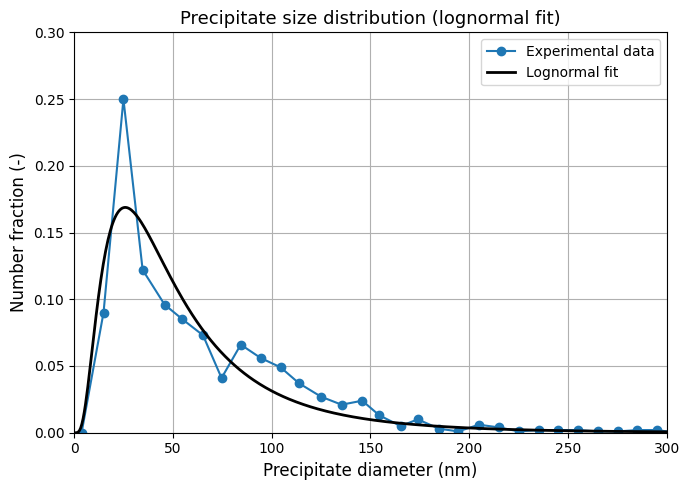

In [20]:
Precipitates = ([3.819, 14.931, 25.000, 34.722, 45.833, 54.861, 65.278, 74.653, 84.375, 94.444, 104.514, 113.889, 125.000, 135.417, 145.833, 154.514, 165.278, 173.958, 184.722, 194.444, 204.861, 214.931, 225.000, 235.069, 244.792, 254.861, 264.931, 275.347, 285.069, 294.792, 304.861, 315.278, 324.653], [0.00001, 0.090, 0.250, 0.122, 0.096, 0.085, 0.073, 0.041, 0.066, 0.056, 0.049, 0.037, 0.027, 0.021, 0.024, 0.013, 0.005, 0.010, 0.003, 0.001, 0.006, 0.004, 0.001, 0.002, 0.002, 0.002, 0.001, 0.001, 0.002, 0.002, 0.000, 0.002, 0.000])
x_data, y_data = Precipitates[0], Precipitates[1]

p0 = [10, 50, 30] # Initial guesses: A, mean, std
popt, pcov = curve_fit(fit_lognormal, x_data, y_data, p0=p0, maxfev=10000)
A_fit, mean_fit, std_fit = popt

xfit = np.linspace(1, 300, 500)
yfit = fit_lognormal(xfit, *popt)

sigma = np.sqrt(np.log(1 + (std_fit / mean_fit)**2))
mu = np.log(mean_fit) - 0.5 * sigma**2
mean_theoretical = np.exp(mu + 0.5 * sigma**2)
var_theoretical  = (np.exp(sigma**2) - 1) * np.exp(2*mu + sigma**2)
std_theoretical  = np.sqrt(var_theoretical)
skew_theoretical = (np.exp(sigma**2) + 2) * np.sqrt(np.exp(sigma**2) - 1)
kurt_theoretical = np.exp(4*sigma**2) + 2*np.exp(3*sigma**2) + 3*np.exp(2*sigma**2)

print(f"Lognormal fit parameters:")
print(f"  A = {A_fit:.3f}")
print(f"  mean = {mean_fit:.2f} nm")
print(f"  std  = {std_fit:.2f} nm")
print(f"\nFitted lognormal moments:")
print(f"  Mean     = {mean_theoretical:.2f} nm")
print(f"  Variance = {var_theoretical:.2f} nm^2  (Std = {std_theoretical:.2f} nm)")
print(f"  Skewness = {skew_theoretical:.3f}")
print(f"  Kurtosis = {kurt_theoretical:.3f}")

plt.figure(figsize=(7, 5))
plt.plot(x_data, y_data, '-o', color='tab:blue', label='Experimental data')
plt.plot(xfit, yfit, 'k-', lw=2, label='Lognormal fit')
plt.xlabel('Precipitate diameter (nm)', fontsize=12)
plt.ylabel('Number fraction (-)', fontsize=12)
plt.title('Precipitate size distribution (lognormal fit)', fontsize=13)
plt.xlim(0, 300)
plt.ylim(0, 0.3)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()